#### Import packages

In [40]:
import sys, os, os.path as osp
import argparse
import numpy as np
import pandas as pd
import time
from functools import partial
from scipy.stats import percentileofscore as POS
from itertools import permutations
from glob import glob
from collections import defaultdict
from sklearn.metrics import precision_recall_curve,auc
from scipy.stats import percentileofscore
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

IN = '../../data/Toxicity_Analysis/'
OUT = '../../output/Toxicity_Analysis/'
TOX = '../../output/Drug_Combination_Prediction/'
TOX_IN = '../../data/Drug_Combination_Prediction/'

# Fig. S3

In [17]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
def experimental_drug_2_names_single(mvr,TOX_NM_2_COM,single_drugs):
    exp_drug_names = set(mvr.drug1_name.values.tolist())&set(mvr.drug2_name.values.tolist())
    exp_name_conversion_d = dict([(elt2,set([elt for elt in TOX_NM_2_COM.values if elt2 in elt])) for elt2 in exp_drug_names])
    nms2del = []
    for nm,val in exp_name_conversion_d.items():
        if len(val)==0:
            if nm=='omiplasib':
                exp_name_conversion_d[nm]='gsk-2126458'
            else:
                nms2del.append(nm)
        elif len(val)==1:
            exp_name_conversion_d[nm]=val.pop()
        else:
            if nm=='oxacillin':
                exp_name_conversion_d[nm]=nm
            else:
                print(nm,val)
    for elt in nms2del:
        del exp_name_conversion_d[elt]
    EXP_NM_2_COM = pd.Series(exp_name_conversion_d)
    exp_tox_dat = []
    for drg,row in mvr.iterrows():
        if isinstance(row.loc['drug2_name'],float):
            if not row.loc['drug1_name'] in EXP_NM_2_COM.index:
                continue
            drg = EXP_NM_2_COM.loc[row.loc['drug1_name']]
            if not drg in single_drugs.index:
                continue
            conc = row.loc['drug1_uM']
            row_d = {'drug1_name':drg,'drug2_name':np.nan,'drug1_uM':conc,'drug2_uM':np.nan}
            for cl,clvia in row.iloc[-4:].items():
                row_d[f'via_{cl}']=clvia
            row_d['pred_tox_alt_obj_kernel_0221'] = single_drugs.loc[drg]
            #for colnm,colval in col_data.items():
            #    row_d[f'pred_tox_{colnm}'] = colval        
            ## need to get the associated toxicity prediction.
            row_ser = pd.Series(row_d)
            exp_tox_dat.append(row_ser)
    exp_tox_dat = pd.concat(exp_tox_dat,axis=1).T    
    return EXP_NM_2_COM, exp_tox_dat

def experimental_drug_2_names_pairs(mvr,TOX_NM_2_COM,pair_drugs):
    exp_drug_names = set(mvr.drug1_name.values.tolist())&set(mvr.drug2_name.values.tolist())
    exp_name_conversion_d = dict([(elt2,set([elt for elt in TOX_NM_2_COM.values if elt2 in elt])) for elt2 in exp_drug_names])
    nms2del = []
    for nm,val in exp_name_conversion_d.items():
        if len(val)==0:
            if nm=='omiplasib':
                exp_name_conversion_d[nm]='gsk-2126458'
            else:
                nms2del.append(nm)
        elif len(val)==1:
            exp_name_conversion_d[nm]=val.pop()
        else:
            if nm=='oxacillin':
                exp_name_conversion_d[nm]=nm
            else:
                print(nm,val)
    for elt in nms2del:
        del exp_name_conversion_d[elt]
    EXP_NM_2_COM = pd.Series(exp_name_conversion_d)
    exp_tox_dat = []
    for drg,row in mvr.iterrows():
        if not isinstance(row.loc['drug2_name'],float):
            if not (row.loc['drug1_name'] in EXP_NM_2_COM.index and row.loc['drug2_name'] in EXP_NM_2_COM.index):
                continue
            drg1 = EXP_NM_2_COM.loc[row.loc['drug1_name']]
            drg2 = EXP_NM_2_COM.loc[row.loc['drug2_name']]
            if not (drg2 in pair_drugs.loc[drg1].index or drg1 in pair_drugs.loc[drg2].index):
                continue
            if drg1 in pair_drugs.loc[drg2].index:
                (drg1,drg2) = (drg2,drg1)
            conc1 = row.loc['drug1_uM']
            conc2 = row.loc['drug2_uM']
            row_d = {'drug1_name':drg1,'drug2_name':drg2,'drug1_uM':conc1,'drug2_uM':conc2}
            for cl,clvia in row.iloc[-4:].items():
                row_d[f'via_{cl}']=clvia
            colval = pair_drugs.xs((drg1,drg2),level=[0,1]).mean()
            row_d['pred_tox_alt_obj_kernel_0221'] = colval
            #for colnm,colval in pair_drugs.xs((drg1,drg2),level=[0,1]).mean().items():
            ## need to get the associated toxicity prediction.
            row_ser = pd.Series(row_d)
            exp_tox_dat.append(row_ser)
    exp_tox_dat = pd.concat(exp_tox_dat,axis=1).T    
    return EXP_NM_2_COM, exp_tox_dat

def toxicity_drug_2_names(single_drugs):
    lc_drug_names = []
    for elt in single_drugs.index.get_level_values(-1):
        if '---' in elt:
            brd = elt.split('---')[0]
            cand_name = cmp_info.loc[brd].cmap_name
            cand_name = cand_name if isinstance(cand_name,str) else cand_name.unique()[-1]
        else:
            cand_name = elt
        lc_drug_names.append((elt,cand_name.lower()))
    TOX_NM_2_COM = pd.Series(dict(lc_drug_names))
    return TOX_NM_2_COM

def toxicity_drug_2_names_pairs(pair_drugs):
    lc_drug_names = []
    for col in [-2,-1]:
        for elt in pair_drugs.index.get_level_values(-2):
            if '---' in elt:
                brd = elt.split('---')[0]
                cand_name = cmp_info.loc[brd].cmap_name
                cand_name = cand_name if isinstance(cand_name,str) else cand_name.unique()[-1]
            else:
                cand_name = elt
            lc_drug_names.append((elt,cand_name.lower()))    
    TOX_NM_2_COM = pd.Series(dict(lc_drug_names))
    return TOX_NM_2_COM

def optimized_drug_2_names(pred_state_gsm):
    d1_un = pred_state_gsm.index.get_level_values(-2).unique()
    d2_un = pred_state_gsm.index.get_level_values(-1).unique()
    all_drgs = set(d1_un)|set(d2_un)
    tup_l = []
    for elt in all_drgs:
        if '---lincs' in elt:
            tup_l.append((elt,elt.split('---lincs')[0]))
        elif elt=='omiplasib':
            tup_l.append((elt,'gsk-2126458'))
        elif elt=='mpa':
            tup_l.append((elt,'progesterone'))
        else:
            tup_l.append((elt,elt))
    OPT_NM_2_COM = pd.Series(dict(tup_l))
    return OPT_NM_2_COM

def single_drug_ranksum(SEL,nm2com):
    sumrank_d = defaultdict(float)
    for (drg1,drg2),val in SEL.items():
        sumrank_d[nm2com.loc[drg1]]+=val
        sumrank_d[nm2com.loc[drg2]]+=val
    return pd.Series(dict(sumrank_d))
def pair_drug_ranksum(SEL,nm2com):
    sumrank_d = defaultdict(float)
    for (drg1,drg2),val in SEL.items():
        srt_key = tuple(sorted([nm2com.loc[drg1],nm2com.loc[drg2]]))
        sumrank_d[srt_key]+=val
    return pd.Series(dict(sumrank_d))
    

### Fig. S3A

In [8]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from collections import defaultdict
cl_abbr_l = ['43','CH','Io','LN']
ds_l = ['CGGA', 'Couturier2020', 'GSE131928', 'GSE84465', 'lincs', 'Richards2021']
ds2_nm_d = {'Couturier2020':'Couturier_et_al_2020',
            'CGGA':'CGGA',
            'lincs':'lincs',
            'Richards2021':'Richards_et_al_2021',
            'Neftel_et_al_2019':'GSE131928',
            'Darmanis_et_al_2017':'GSE84465'}
op_d2 = pd.read_pickle(f'{IN}/growth_signature_viability_stats.pkl')
op_d = pd.read_pickle(f'{IN}/growth_signature_selected_v_unselected.pkl')

### Boxplot of AUC-ROC between assay viability and toxicity change

In [35]:
rocauc_lbl_d = {}
scc_lbl_d = {}
add_cl_points_d = defaultdict(dict)
nadd_cl_points_d = defaultdict(dict)

stat_name = 'logPT_mean' ## could do logPT_mean or rocauc
add_grow_method_scc_d = defaultdict(list)
nadd_grow_method_scc_d = defaultdict(list)
add_rpg_method_scc_d = defaultdict(list)
nadd_rpg_method_scc_d = defaultdict(list)
add_comb_method_scc_d = defaultdict(list)
nadd_comb_method_scc_d = defaultdict(list)


ind = 0
ind2 = 0
for ds in ds_l:    
    ds_PAIRS =  pd.read_table(f'{TOX_IN}/{ds2_nm_d[ds]}/pairs.tsv')
    ds_STATES = pd.read_table(f'{TOX_IN}/{ds2_nm_d[ds]}/states.tsv')
    init_state_inds = ds_PAIRS.iloc[:,0].unique()
    targ_state_inds = ds_PAIRS.iloc[:,1].unique()
    init_states = ds_STATES.loc[init_state_inds,'state_name'].unique()
    targ_states = ds_STATES.loc[targ_state_inds,'state_name'].unique()    
    for sp in ['single','pair']:
        rocauc_lbl_d[(ds,sp)]=ind
        for ana in ['add','nadd']:
            sel_keys = [kw for kw in op_d2.keys() if tuple(kw[:3])==(ds,ana,sp)]
            if ana=='add':
                for cl in cl_abbr_l:
                    add_cl_points_d[(ds,sp)][cl] = [op_d2[kw] for kw in sel_keys if kw[-2]==cl and kw[3] in init_states]
                add_cl_points_d[(ds,sp)]['median'] = [op_d2[kw] for kw in sel_keys if kw[-2]=='median' and kw[3] in init_states]
            else:
                for cl in cl_abbr_l:
                    nadd_cl_points_d[(ds,sp)][cl] = [op_d2[kw] for kw in sel_keys if kw[-2]==cl and kw[3] in init_states]
                nadd_cl_points_d[(ds,sp)]['median'] = [op_d2[kw] for kw in sel_keys if kw[-2]=='median' and kw[3] in init_states]
            for cst in ['0.00','0.79','1.57']:
                scc_lbl_d[(ds,sp,cst,ana)]=ind2
                mkeys = [kw for kw in op_d.keys() if tuple(kw[:3])==(ds,ana,sp) and tuple(kw[4:])==(cst,stat_name) and kw[3] in init_states]
                if (ana,cst)==('add','0.00'):
                    add_rpg_method_scc_d[(ds,sp)].extend([op_d[kw] for kw in mkeys])
                elif (ana,cst)==('add','0.79'):
                    add_comb_method_scc_d[(ds,sp)].extend([op_d[kw] for kw in mkeys])
                elif (ana,cst)==('add','1.57'):
                    add_grow_method_scc_d[(ds,sp)].extend([op_d[kw] for kw in mkeys])
                elif (ana,cst)==('nadd','0.00'):
                    nadd_rpg_method_scc_d[(ds,sp)].extend([op_d[kw] for kw in mkeys])
                elif (ana,cst)==('nadd','0.79'):
                    nadd_comb_method_scc_d[(ds,sp)].extend([op_d[kw] for kw in mkeys])
                elif (ana,cst)==('nadd','1.57'):
                    nadd_grow_method_scc_d[(ds,sp)].extend([op_d[kw] for kw in mkeys])
                ind2+=1
        ind+=1

#rocauc_lbl_d = dict(rocauc_lbl_d)
add_cl_points_d = dict(add_cl_points_d)
nadd_cl_points_d = dict(nadd_cl_points_d)

add_grow_method_scc_d = dict(add_grow_method_scc_d)
nadd_grow_method_scc_d = dict(nadd_grow_method_scc_d)
add_rpg_method_scc_d = dict(add_rpg_method_scc_d)
nadd_rpg_method_scc_d = dict(nadd_rpg_method_scc_d)
add_comb_method_scc_d = dict(add_comb_method_scc_d)
nadd_comb_method_scc_d = dict(nadd_comb_method_scc_d)

In [36]:

boxvals_add_single_l = []
boxvals_add_pair_l = []
boxvals_nadd_single_l = []
boxvals_nadd_pair_l = []

cl_add_single_data_d=defaultdict(list)
cl_add_pair_data_d=defaultdict(list)
cl_nadd_single_data_d=defaultdict(list)
cl_nadd_pair_data_d=defaultdict(list)
for (ds,sop),cl_pts_d in add_cl_points_d.items():
    boxvals_add_single = []
    boxvals_add_pair = []
    boxvals_nadd_single = []
    boxvals_nadd_pair = []
    for cl,val in cl_pts_d.items():
        if cl=='median':
            if sop=='single':
                boxvals_add_single.extend(list(val))
                cl_add_single_data_d[(cl,'xvals')].extend((np.random.rand(len(val))-0.5)*0.5+2*len(boxvals_add_single_l))
                cl_add_single_data_d[(cl,'yvals')].extend(val)
            else:
                boxvals_add_pair.extend(list(val))
                cl_add_pair_data_d[(cl,'xvals')].extend((np.random.rand(len(val))-0.5)*0.5+2*len(boxvals_add_pair_l))
                cl_add_pair_data_d[(cl,'yvals')].extend(val)
    cl_pts_d2 = nadd_cl_points_d[(ds,sop)]
    for cl2,val2 in cl_pts_d2.items():
        if cl2=='median':
            if sop=='single':
                boxvals_nadd_single.extend(list(val2))
                cl_nadd_single_data_d[(cl2,'xvals')].extend((np.random.rand(len(val2))-0.5)*0.5+2*len(boxvals_nadd_single_l)+1)
                cl_nadd_single_data_d[(cl2,'yvals')].extend(val2)
            else:
                boxvals_nadd_pair.extend(list(val2))
                cl_nadd_pair_data_d[(cl2,'xvals')].extend((np.random.rand(len(val2))-0.5)*0.5+2*len(boxvals_nadd_pair_l)+1)
                cl_nadd_pair_data_d[(cl2,'yvals')].extend(val2)                
    if sop=='single':
        boxvals_add_single_l.append(boxvals_add_single)
        boxvals_nadd_single_l.append(boxvals_nadd_single)
    else:
        boxvals_add_pair_l.append(boxvals_add_pair)
        boxvals_nadd_pair_l.append(boxvals_nadd_pair)


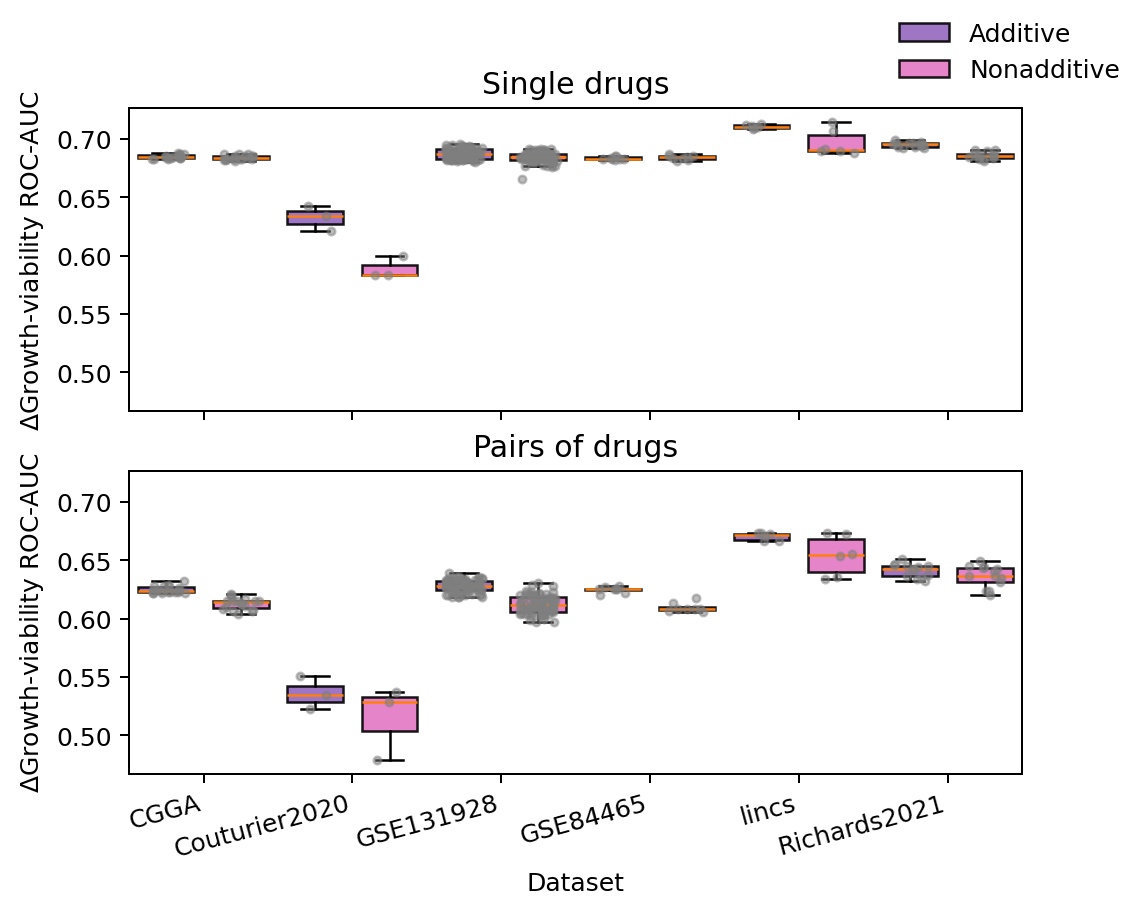

In [11]:
xvals = np.arange(len(boxvals_add_single_l))
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'
fig,ax_arr = plt.subplots(2,1,dpi=180,sharex=True,sharey=True)
boxout1 = ax_arr[0].boxplot(boxvals_add_single_l,positions=2*xvals,widths=0.75,patch_artist=True,boxprops={'facecolor':'C3','alpha':0.9},showfliers=False,zorder=1)
boxout2 = ax_arr[0].boxplot(boxvals_nadd_single_l,positions=2*xvals+1,widths=0.75,patch_artist=True,boxprops={'facecolor':'C4','alpha':0.9},showfliers=False,zorder=1)
boxout3 = ax_arr[1].boxplot(boxvals_add_pair_l,positions=2*xvals,widths=0.75,patch_artist=True,boxprops={'facecolor':'C3','alpha':0.9},showfliers=False,zorder=1)
boxout4 = ax_arr[1].boxplot(boxvals_nadd_pair_l,positions=2*xvals+1,widths=0.75,patch_artist=True,boxprops={'facecolor':'C4','alpha':0.9},showfliers=False,zorder=1)
ax_arr[0].set_title('Single drugs')
ax_arr[1].set_title('Pairs of drugs')
#ax.set_xlim(0,25)
for jj,cl in enumerate(cl_abbr_l+['median']):
    ax_arr[0].scatter(cl_add_single_data_d[(cl,'xvals')], cl_add_single_data_d[(cl,'yvals')], marker='.',color=f'C7',label=cl,alpha=0.5,zorder=2)
    ax_arr[1].scatter(cl_add_pair_data_d[(cl,'xvals')],   cl_add_pair_data_d[(cl,'yvals')],   marker='.',color=f'C7',label=cl,alpha=0.5,zorder=2)
    ax_arr[0].scatter(cl_nadd_single_data_d[(cl,'xvals')],cl_nadd_single_data_d[(cl,'yvals')],marker='.',color=f'C7',alpha=0.5,zorder=2)
    ax_arr[1].scatter(cl_nadd_pair_data_d[(cl,'xvals')],  cl_nadd_pair_data_d[(cl,'yvals')],  marker='.',color=f'C7',alpha=0.5,zorder=2)



ax_arr[0].set_ylabel(r'$\Delta$Growth-viability ROC-AUC')
ax_arr[1].set_ylabel(r'$\Delta$Growth-viability ROC-AUC')
ax_arr[1].set_xlabel('Dataset')
for row in range(2):
    ax_arr[row].set_xticks(2*np.arange(len(boxvals_add_single_l))+0.5)
#ax_arr[0].set_xticklabels([f'' for ds in ds_l],rotation=15,horizontalalignment='right')
ax_arr[1].set_xticklabels([f'{ds}' for ds in ds_l],rotation=15,horizontalalignment='right')
fig.legend(handles=[boxout1['boxes'][0],boxout2['boxes'][0]],labels=['Additive','Nonadditive'],frameon=False)
fig.savefig(f'{OUT}/growthchange_viability_boxplot.svg')

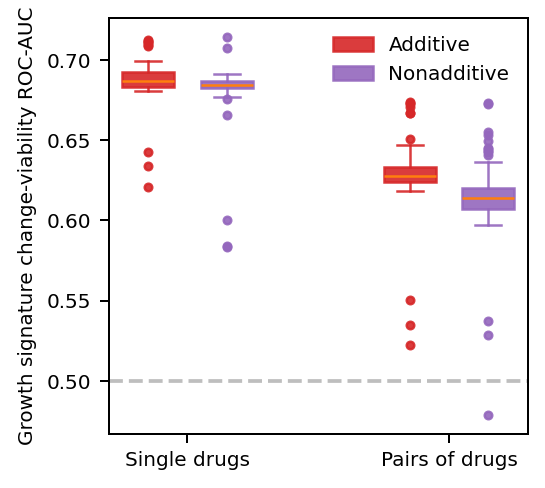

In [38]:

boxvals_add_single_l = []
boxvals_add_pair_l = []
boxvals_nadd_single_l = []
boxvals_nadd_pair_l = []

for (ds,sop),cl_pts_d in add_cl_points_d.items():
    for cl,val in cl_pts_d.items():
        if cl=='median':
            if sop=='single':
                boxvals_add_single_l.extend(list(val))
            else:
                boxvals_add_pair_l.extend(list(val))
    cl_pts_d2 = nadd_cl_points_d[(ds,sop)]
    for cl2,val2 in cl_pts_d2.items():
        if cl2=='median':
            if sop=='single':
                boxvals_nadd_single_l.extend(list(val2))
            else:
                boxvals_nadd_pair_l.extend(list(val2))

fig,ax = plt.subplots(1,1,figsize=(3,3),dpi=180)
boxout1 = ax.boxplot([boxvals_add_single_l,boxvals_add_pair_l],positions=np.arange(2),widths=0.2,patch_artist=True,
                     boxprops={'facecolor':'C3','edgecolor':'C3','alpha':0.9},
                     whiskerprops={'color':'C3','alpha':0.9},capprops={'color':'C3','alpha':0.9},
                     flierprops={'markerfacecolor':'C3','markeredgecolor':'C3','marker':'.','alpha':0.9},
                     zorder=1)
boxout2 = ax.boxplot([boxvals_nadd_single_l,boxvals_nadd_pair_l],positions=np.arange(2)+0.3,widths=0.2,patch_artist=True,
                     boxprops={'facecolor':'C4','edgecolor':'C4','alpha':0.9},
                     whiskerprops={'color':'C4','alpha':0.9},capprops={'color':'C4','alpha':0.9},
                     flierprops={'markerfacecolor':'C4','markeredgecolor':'C4','marker':'.','alpha':0.9},
                     zorder=1)



ax.set_ylabel(r'Growth signature change-viability ROC-AUC',size=8)
plt.setp(ax.get_yticklabels(),size=8)
ax.axhline(0.5,ls='--',color='C7',zorder=1,alpha=0.5)
ax.set_xticks([0.15,1.15])
ax.set_xticklabels(['Single drugs','Pairs of drugs'],size=8)
ax.set_xlim(-.15,1.45)

ax.legend(handles=[boxout1['boxes'][0],boxout2['boxes'][0]],labels=['Additive','Nonadditive'],frameon=False,prop={'size':8})
fig.savefig(f'{OUT}/figS3a_growthchange_viability_boxplot_agg.svg')


## Fig. S3B

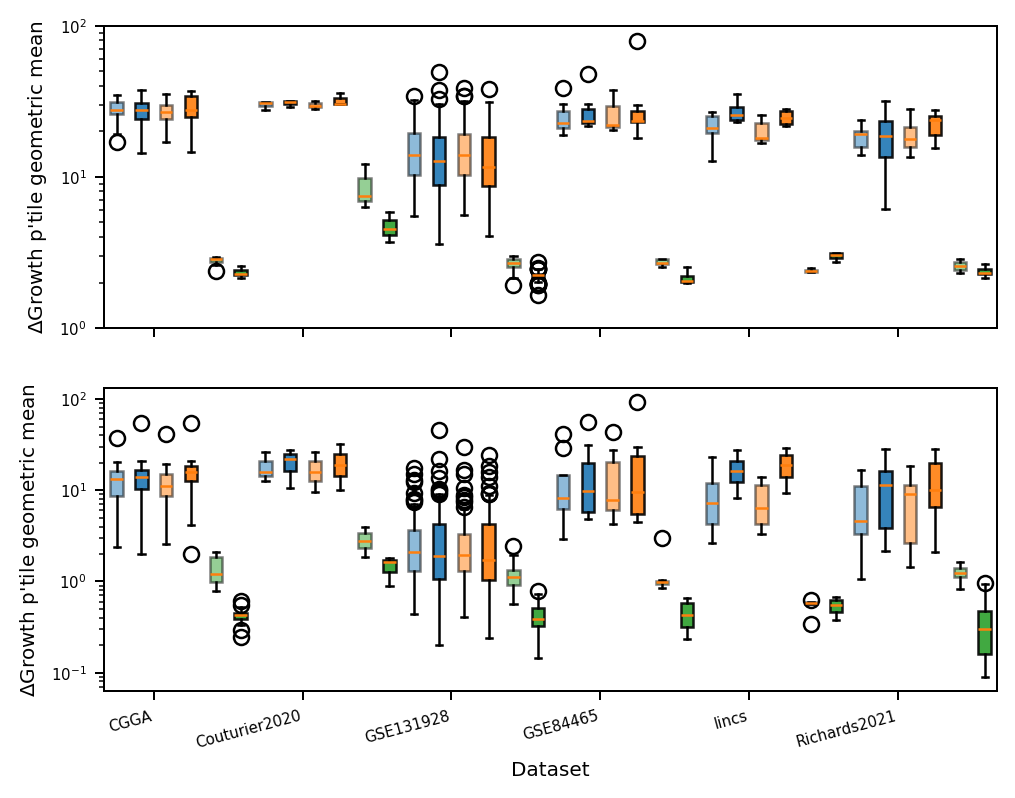

In [13]:
bxdat_add_rpg_single = [[10**(elt)  for elt in add_rpg_method_scc_d[(ds,'single')]]  for ds in ds_l ] 
bxdat_add_rpg_pair = [[10**(elt) for elt in add_rpg_method_scc_d[(ds,'pair')]]  for ds in ds_l] 
bxdat_add_rpg_pos = [scc_lbl_d[(ds,'single','0.00','add')]//2 for ds in ds_l] 

bxdat_nadd_rpg_single = [[10**(elt)  for elt in nadd_rpg_method_scc_d[(ds,'single')]]  for ds in ds_l ] 
bxdat_nadd_rpg_pair = [[10**(elt) for elt in nadd_rpg_method_scc_d[(ds,'pair')]]  for ds in ds_l] 
bxdat_nadd_rpg_pos = [scc_lbl_d[(ds,'single','0.00','add')]//2+1 for ds in ds_l] 

bxdat_add_comb_single = [[10**(elt)  for elt in add_comb_method_scc_d[(ds,'single')]]  for ds in ds_l ] 
bxdat_add_comb_pair = [[10**(elt) for elt in add_comb_method_scc_d[(ds,'pair')]]  for ds in ds_l] 
bxdat_add_comb_pos = [scc_lbl_d[(ds,'single','0.00','add')]//2+2 for ds in ds_l] 

bxdat_nadd_comb_single = [[10**(elt)  for elt in nadd_comb_method_scc_d[(ds,'single')]]  for ds in ds_l ] 
bxdat_nadd_comb_pair = [[10**(elt) for elt in nadd_comb_method_scc_d[(ds,'pair')]]  for ds in ds_l] 
bxdat_nadd_comb_pos = [scc_lbl_d[(ds,'single','0.00','add')]//2+3 for ds in ds_l] 

bxdat_add_grow_single = [[10**(elt)  for elt in add_grow_method_scc_d[(ds,'single')]]  for ds in ds_l ] 
bxdat_add_grow_pair = [[10**(elt) for elt in add_grow_method_scc_d[(ds,'pair')]]  for ds in ds_l] 
bxdat_add_grow_pos = [scc_lbl_d[(ds,'single','0.00','add')]//2+4 for ds in ds_l] 

bxdat_nadd_grow_single = [[10**(elt)  for elt in nadd_grow_method_scc_d[(ds,'single')]]  for ds in ds_l ] 
bxdat_nadd_grow_pair = [[10**(elt) for elt in nadd_grow_method_scc_d[(ds,'pair')]]  for ds in ds_l] 
bxdat_nadd_grow_pos = [scc_lbl_d[(ds,'single','0.00','add')]//2+5for ds in ds_l] 

# bxpos1 = [scc_lbl_d[(ds,sp,'0.00','add')] for ds in ds_l for sp in ['single','pair']]
# bxdat2 = [[elt[0]*-1 if sp=='single' else elt[0] for elt in nadd_rpg_method_scc_d[(ds,sp)]]  for ds in ds_l for sp in ['single','pair']] 
# bxpos2 = [scc_lbl_d[(ds,sp,'0.00','nadd')] for ds in ds_l for sp in ['single','pair']]
# bxdat3 = [[elt[0]*-1 if sp=='single' else elt[0] for elt in add_comb_method_scc_d[(ds,sp)]]  for ds in ds_l for sp in ['single','pair']] 
# bxpos3 = [scc_lbl_d[(ds,sp,'0.79','add')] for ds in ds_l for sp in ['single','pair']]
# bxdat4 = [[elt[0]*-1 if sp=='single' else elt[0] for elt in nadd_comb_method_scc_d[(ds,sp)]]  for ds in ds_l for sp in ['single','pair']] 
# bxpos4 = [scc_lbl_d[(ds,sp,'0.79','nadd')] for ds in ds_l for sp in ['single','pair']]
# bxdat5 = [[elt[0]*-1 if sp=='single' else elt[0] for elt in add_grow_method_scc_d[(ds,sp)]]  for ds in ds_l for sp in ['single','pair']] 
# bxpos5 = [scc_lbl_d[(ds,sp,'1.57','add')] for ds in ds_l for sp in ['single','pair']]
# bxdat6 = [[elt[0]*-1 if sp=='single' else elt[0] for elt in nadd_grow_method_scc_d[(ds,sp)]]  for ds in ds_l for sp in ['single','pair']] 
# bxpos6 = [scc_lbl_d[(ds,sp,'1.57','nadd')] for ds in ds_l for sp in ['single','pair']]

fig,ax_arr = plt.subplots(2,1,dpi=180,sharex=True)
ax_arr[0].boxplot(bxdat_add_rpg_single,positions=bxdat_add_rpg_pos,patch_artist=True,boxprops={'facecolor':'C0','alpha':0.5})
ax_arr[1].boxplot(bxdat_add_rpg_pair,positions=bxdat_add_rpg_pos,patch_artist=True,boxprops={'facecolor':'C0','alpha':0.5})
ax_arr[0].boxplot(bxdat_nadd_rpg_single,positions=bxdat_nadd_rpg_pos,patch_artist=True,boxprops={'facecolor':'C0','alpha':0.9})
ax_arr[1].boxplot(bxdat_nadd_rpg_pair,positions=bxdat_nadd_rpg_pos,patch_artist=True,boxprops={'facecolor':'C0','alpha':0.9})
ax_arr[0].boxplot(bxdat_add_comb_single,positions=bxdat_add_comb_pos,patch_artist=True,boxprops={'facecolor':'C1','alpha':0.5})
ax_arr[1].boxplot(bxdat_add_comb_pair,positions=bxdat_add_comb_pos,patch_artist=True,boxprops={'facecolor':'C1','alpha':0.5})
ax_arr[0].boxplot(bxdat_nadd_comb_single,positions=bxdat_nadd_comb_pos,patch_artist=True,boxprops={'facecolor':'C1','alpha':0.9})
ax_arr[1].boxplot(bxdat_nadd_comb_pair,positions=bxdat_nadd_comb_pos,patch_artist=True,boxprops={'facecolor':'C1','alpha':0.9})
ax_arr[0].boxplot(bxdat_add_grow_single,positions=bxdat_add_grow_pos,patch_artist=True,boxprops={'facecolor':'C2','alpha':0.5})
ax_arr[1].boxplot(bxdat_add_grow_pair,positions=bxdat_add_grow_pos,patch_artist=True,boxprops={'facecolor':'C2','alpha':0.5})
ax_arr[0].boxplot(bxdat_nadd_grow_single,positions=bxdat_nadd_grow_pos,patch_artist=True,boxprops={'facecolor':'C2','alpha':0.9})
ax_arr[1].boxplot(bxdat_nadd_grow_pair,positions=bxdat_nadd_grow_pos,patch_artist=True,boxprops={'facecolor':'C2','alpha':0.9})
# ax.boxplot(bxdat1,positions=bxpos1,patch_artist=True,boxprops={'facecolor':'C0','alpha':0.5})
# ax.boxplot(bxdat2,positions=bxpos2,patch_artist=True,boxprops={'facecolor':'C0','alpha':0.9})
# ax.boxplot(bxdat3,positions=bxpos3,patch_artist=True,boxprops={'facecolor':'C1','alpha':0.5})
# ax.boxplot(bxdat4,positions=bxpos4,patch_artist=True,boxprops={'facecolor':'C1','alpha':0.9})
# ax.boxplot(bxdat5,positions=bxpos5,patch_artist=True,boxprops={'facecolor':'C2','alpha':0.5})
# ax.boxplot(bxdat6,positions=bxpos6,patch_artist=True,boxprops={'facecolor':'C2','alpha':0.9})
ax_arr[1].set_xticks(6*(np.arange(6)+0.25))
tls = [f'{ds}' for ds in ds_l]
plt.setp(ax_arr[1].get_yticklabels(),size=6)
plt.setp(ax_arr[0].get_yticklabels(),size=6)
ax_arr[1].set_xticklabels(tls,rotation=15,size=6,horizontalalignment='right')
ax_arr[0].set_ylabel(r"$\Delta$Growth p'tile geometric mean",size=8)
ax_arr[0].set_yscale('log')
ax_arr[0].set_ylim(1,100)
ax_arr[1].set_ylabel(r"$\Delta$Growth p'tile geometric mean",size=8)
ax_arr[1].set_yscale('log')
ax_arr[1].set_xlabel('Dataset',size=8)
fig.savefig(f'{OUT}/growth_change_percentiles.svg')

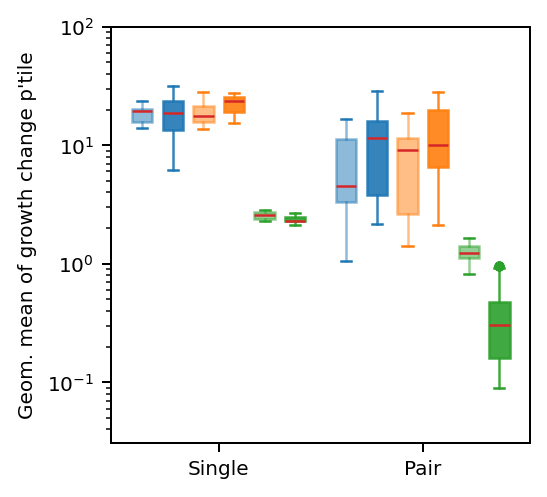

In [14]:
bxdat_add_rpg_single = [10**(elt)  for elt in add_rpg_method_scc_d[(ds,'single')]  for ds in ds_l ]
bxdat_add_rpg_pair = [10**(elt) for elt in add_rpg_method_scc_d[(ds,'pair')]  for ds in ds_l]


bxdat_nadd_rpg_single = [10**(elt)  for elt in nadd_rpg_method_scc_d[(ds,'single')]  for ds in ds_l ]
bxdat_nadd_rpg_pair = [10**(elt) for elt in nadd_rpg_method_scc_d[(ds,'pair')]  for ds in ds_l]


bxdat_add_comb_single = [10**(elt)  for elt in add_comb_method_scc_d[(ds,'single')]  for ds in ds_l ]
bxdat_add_comb_pair = [10**(elt) for elt in add_comb_method_scc_d[(ds,'pair')]  for ds in ds_l]


bxdat_nadd_comb_single = [10**(elt)  for elt in nadd_comb_method_scc_d[(ds,'single')]  for ds in ds_l ]
bxdat_nadd_comb_pair = [10**(elt) for elt in nadd_comb_method_scc_d[(ds,'pair')]  for ds in ds_l]


bxdat_add_grow_single = [10**(elt)  for elt in add_grow_method_scc_d[(ds,'single')]  for ds in ds_l ]
bxdat_add_grow_pair = [10**(elt) for elt in add_grow_method_scc_d[(ds,'pair')]  for ds in ds_l]


bxdat_nadd_grow_single = [10**(elt)  for elt in nadd_grow_method_scc_d[(ds,'single')]  for ds in ds_l ]
bxdat_nadd_grow_pair = [10**(elt) for elt in nadd_grow_method_scc_d[(ds,'pair')]  for ds in ds_l]


fig,ax = plt.subplots(1,1,figsize=(3,3),dpi=180,sharex=True)

ax.boxplot([bxdat_add_rpg_single,bxdat_add_rpg_pair],positions=np.arange(2),widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C0','edgecolor':'C0','alpha':0.5},
           flierprops={'markerfacecolor':'C0','markeredgecolor':'C0','marker':'.','alpha':0.5},
           whiskerprops={'color':'C0','alpha':0.5},
           capprops={'color':'C0'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([bxdat_nadd_rpg_single,bxdat_nadd_rpg_pair],positions=np.arange(2)+0.15,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C0','edgecolor':'C0','alpha':0.9},
           flierprops={'markerfacecolor':'C0','markeredgecolor':'C0','marker':'.','alpha':0.9},
           whiskerprops={'color':'C0','alpha':0.9},
           capprops={'color':'C0'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([bxdat_add_comb_single,bxdat_add_comb_pair],positions=np.arange(2)+0.3,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C1','edgecolor':'C1','alpha':0.5},
           flierprops={'markerfacecolor':'C1','markeredgecolor':'C1','marker':'.','alpha':0.5},
           whiskerprops={'color':'C1','alpha':0.5},
           capprops={'color':'C1'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([bxdat_nadd_comb_single,bxdat_nadd_comb_pair],positions=np.arange(2)+0.45,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C1','edgecolor':'C1','alpha':0.9},
           flierprops={'markerfacecolor':'C1','markeredgecolor':'C1','marker':'.','alpha':0.9},
           whiskerprops={'color':'C1','alpha':0.9},
           capprops={'color':'C1'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([bxdat_add_grow_single,bxdat_add_grow_pair],positions=np.arange(2)+0.6,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C2','edgecolor':'C2','alpha':0.5},
           flierprops={'markerfacecolor':'C2','markeredgecolor':'C2','marker':'.','alpha':0.5},
           whiskerprops={'color':'C2','alpha':0.5},
           capprops={'color':'C2'},medianprops={'color':'C3'},zorder=2)


ax.boxplot([bxdat_nadd_grow_single,bxdat_nadd_grow_pair],positions=np.arange(2)+0.75,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C2','edgecolor':'C2','alpha':0.9},
           flierprops={'markerfacecolor':'C2','markeredgecolor':'C2','marker':'.','alpha':0.9},
           whiskerprops={'color':'C2','alpha':0.9},
           capprops={'color':'C2'},medianprops={'color':'C3'},zorder=2)


ax.set_ylabel(r"Geom. mean of growth change p'tile",size=8)
plt.setp(ax.get_yticklabels(),size=8)
ax.set_yscale('log')
ax.set_ylim(0.031,100)
ax.set_xlim(-.15,1.9)
ax.set_xticks([0.375,1.375])
ax.set_xticklabels(['Single','Pair'],size=8)
fig.savefig(f'{OUT}/figS3b_growth_change_percentiles_agg.svg')


In [16]:
from scipy.stats import wilcoxon
print('add single comb', wilcoxon(bxdat_add_comb_single,bxdat_add_grow_single))
print('add single rpg',wilcoxon(bxdat_add_rpg_single,bxdat_add_grow_single))
print('nadd single comb',wilcoxon(bxdat_nadd_comb_single,bxdat_nadd_grow_single))
print('nadd single rpg',wilcoxon(bxdat_nadd_rpg_single,bxdat_nadd_grow_single))
print('add pair comb',wilcoxon(bxdat_add_comb_pair,bxdat_add_grow_pair))
print('add pair rpg',wilcoxon(bxdat_add_rpg_pair,bxdat_add_grow_pair))
print('nadd pair comb',wilcoxon(bxdat_nadd_comb_pair,bxdat_nadd_grow_pair))
print('nadd pair rpg',wilcoxon(bxdat_nadd_rpg_pair,bxdat_nadd_grow_pair))

add single comb WilcoxonResult(statistic=0.0, pvalue=1.6125422918860882e-14)
add single rpg WilcoxonResult(statistic=0.0, pvalue=1.6125422918860882e-14)
nadd single comb WilcoxonResult(statistic=0.0, pvalue=1.6125422918860882e-14)
nadd single rpg WilcoxonResult(statistic=0.0, pvalue=1.6125422918860882e-14)
add pair comb WilcoxonResult(statistic=0.0, pvalue=1.6125422918860882e-14)
add pair rpg WilcoxonResult(statistic=21.0, pvalue=3.630264890314343e-14)
nadd pair comb WilcoxonResult(statistic=0.0, pvalue=1.6125422918860882e-14)
nadd pair rpg WilcoxonResult(statistic=0.0, pvalue=1.6125422918860882e-14)


## Analysis 2: Compute `delta_tox_d`

In [49]:
#drg_avg_tox_single, drg_avg_tox_pair

## want to make every costF/single/pair 

delta_tox_d = {}

dext = ''
for ds in ds_l:
    ds_PAIRS =  pd.read_table(f'{TOX_IN}/{ds2_nm_d[ds]}/pairs.tsv')
    ds_STATES = pd.read_table(f'{TOX_IN}/{ds2_nm_d[ds]}/states.tsv')
    init_state_inds = ds_PAIRS.iloc[:,0].unique()
    targ_state_inds = ds_PAIRS.iloc[:,1].unique()
    init_states = ds_STATES.loc[init_state_inds,'state_name'].unique()
    targ_states = ds_STATES.loc[targ_state_inds,'state_name'].unique()
    for ana in ['add','nadd']:
        if ana=='add':
            mpred_ser = pd.Series(add_pred_d[ds_key])
            icol = 1
        else:
            mpred_ser = pd.Series(nadd_pred_d[ds_key])
            icol = 2
        for sop_str in ['single','pair']:
            if sop_str=='single':
                tox_data = drg_avg_tox_single #[(ds,ana,csn)]  ## store in the single 
            else:
                tox_data = drg_avg_tox_pair #[(ds,ana,csn)] 
            init_keys = [kw for kw in tox_data.keys() if kw[1]==ana and kw[2] in init_states]
            targ_keys = [kw for kw in tox_data.keys() if kw[1]==ana and kw[2] in targ_states] #tuple(kw[:2])==(ana,sop_str) and kw[-1] in targ_states]
            pair_keys = [(kw1,kw2) for kw1 in tox_data.keys() if kw1[1]==ana and kw1[2] in init_states
                                   for kw2 in tox_data.keys() if kw2[1]==ana and kw2[2] in targ_states]
            avg_init_tox_diff = pd.concat([tox_data[kw] for kw in init_keys],axis=1)
            avg_targ_tox_diff = pd.concat([tox_data[kw] for kw in targ_keys],axis=1)
            avg_pair_tox_diff = pd.concat([tox_data[tkw]-tox_data[ikw] for ikw,tkw in pair_keys],axis=1)
            for costF in ['0.00','0.79','1.57']:
                print((ds,ana,sop_str,costF))
                if ana=='nadd' and ds=='lincs':
                    SEL_COST = mpred_ser.xs(costF,level=0) ## NO CSN is APPLIED HERE!
                    init_ints = ds_STATES[[elt in list(zip(*init_keys))[-1] for elt in ds_STATES.state_name]].index.unique()
                    targ_ints = ds_STATES[[elt in list(zip(*targ_keys))[-1] for elt in ds_STATES.state_name]].index.unique()                    
                    SEL = SEL_COST[SEL_COST.index.get_level_values(0).isin(init_ints)]
                    SEL_TARG = SEL_COST[SEL_COST.index.get_level_values(icol).isin(targ_ints)]
                    ## the pairs need to be selected individually and looped over
                    sel_pair_l = []
                    for ikw,tkw in pair_keys:
                        iint = int(ds_STATES[ds_STATES.state_name==ikw[2]].index[0])
                        tint = int(ds_STATES[ds_STATES.state_name==tkw[2]].index[0])
                        sel_pair_l.append(SEL_COST[(SEL_COST.index.get_level_values(0)==iint)&(SEL_COST.index.get_level_values(icol)==tint)])
                else:
                    SEL_COST = mpred_ser.xs(costF,level=0) ## NO CSN is APPLIED HERE!
                    SEL = SEL_COST[SEL_COST.index.get_level_values(0).isin(init_states)]                    
                    SEL_TARG = SEL_COST[SEL_COST.index.get_level_values(icol).isin(targ_states)]
                    sel_pair_l = []
                    for ikw,tkw in pair_keys:
                        sel_pair_l.append(SEL_COST[(SEL_COST.index.get_level_values(0)==ikw[2])&(SEL_COST.index.get_level_values(icol)==tkw[2])])
                if ana == 'add':
                    SEL = SEL[~SEL.isna()].droplevel([0,1])
                    SEL_TARG = SEL_TARG[~SEL_TARG.isna()].droplevel([0,1])
                    sel_pair_l = [SEL_PAIR[~SEL_PAIR.isna()].droplevel([0,1]) for SEL_PAIR in sel_pair_l] 
                elif ana=='nadd':
                    SEL = SEL[~SEL.isna()].droplevel([0,1,2,3])
                    SEL_TARG = SEL_TARG[~SEL_TARG.isna()].droplevel([0,1,2,3])
                    sel_pair_l = [SEL_PAIR[~SEL_PAIR.isna()].droplevel([0,1,2,3]) for SEL_PAIR in sel_pair_l] 
                nm2com = optimized_drug_2_names(SEL)
                nm2com_targ = optimized_drug_2_names(SEL_TARG)
                nm2com_pair_l = [optimized_drug_2_names(SEL_PAIR) for SEL_PAIR in sel_pair_l]
                if sop_str=='single':
                    ranksum_ser = single_drug_ranksum(SEL,nm2com)
                    IS = ranksum_ser.index.intersection(avg_init_tox_diff.index)
                    if ranksum_ser.loc[IS].shape[0]>50:
                        sel_drug_inds = ranksum_ser.loc[IS].sort_values().tail(25).index
                    else:
                        sel_drug_inds = ranksum_ser.loc[IS].sort_values().iloc[int(ranksum_ser.loc[IS].shape[0]/2):].index
                    
                    ranksum_ser_pair_l = [single_drug_ranksum(SEL_PAIR,nm2com_pair) for SEL_PAIR,nm2com_pair in zip(sel_pair_l,nm2com_pair_l)]
                    IS_pair_l = [ranksum_ser_pair.index.intersection(avg_init_tox_diff.index) for ranksum_ser_pair in ranksum_ser_pair_l]
                    sel_drug_inds_pair_l = []
                    for ranksum_ser_pair,IS_pair in zip(ranksum_ser_pair_l,IS_pair_l):
                        if ranksum_ser_pair.loc[IS_pair].shape[0]>50:
                            sel_drug_inds_pair_l.append(ranksum_ser_pair.loc[IS_pair].sort_values().tail(25).index)
                        else:
                            sel_drug_inds_pair_l.append(ranksum_ser_pair.loc[IS_pair].sort_values().iloc[int(ranksum_ser_pair.loc[IS_pair].shape[0]/2):].index)
                    
                    ranksum_ser_targ = single_drug_ranksum(SEL_TARG,nm2com_targ)
                    IS_targ = ranksum_ser_targ.index.intersection(avg_targ_tox_diff.index)
                    if ranksum_ser_targ.loc[IS_targ].shape[0]>50:
                        sel_drug_inds_targ = ranksum_ser_targ.loc[IS_targ].sort_values().tail(25).index
                    else:
                        sel_drug_inds_targ = ranksum_ser_targ.loc[IS_targ].sort_values().iloc[int(ranksum_ser_targ.loc[IS_targ].shape[0]/2):].index
                elif sop_str=='pair':
                    pair_sel = pd.Series(dict([((nm2com.loc[drg1],nm2com.loc[drg2]),val) for (drg1,drg2),val in SEL.items()]))
                    IS = pair_sel.index.intersection(avg_init_tox_diff.index)
                    if pair_sel.loc[IS].shape[0]>50:
                        sel_drug_inds = pair_sel.loc[IS].sort_values().tail(25).index
                    else:
                        sel_drug_inds = pair_sel.loc[IS].sort_values().iloc[int(pair_sel.loc[IS].shape[0]/2):].index
                    
                    pair_sel_pair_l = []
                    for nm2com_pair,SEL_PAIR in zip(nm2com_pair_l,sel_pair_l):
                        if SEL_PAIR.shape[0]>0:
                            pair_sel_pair_l.append(pd.Series(dict([((nm2com_pair.loc[drg1],nm2com_pair.loc[drg2]),val) for (drg1,drg2),val in SEL_PAIR.items()])))
                    IS_pair_l = [pair_sel_pair.index.intersection(avg_init_tox_diff.index) for pair_sel_pair in pair_sel_pair_l]
                    
                    sel_drug_inds_pair_l = []
                    for pair_sel_pair,IS_pair in zip(pair_sel_pair_l,IS_pair_l):
                        if pair_sel_pair.loc[IS_pair].shape[0]>50:
                            sel_drug_inds_pair_l.append(pair_sel_pair.loc[IS_pair].sort_values().tail(25).index)
                        else:
                            sel_drug_inds_pair_l.append(pair_sel_pair.loc[IS_pair].sort_values().iloc[int(pair_sel_pair.loc[IS_pair].shape[0]/2):].index)

                    pair_sel_targ = pd.Series(dict([((nm2com_targ.loc[drg1],nm2com_targ.loc[drg2]),val) for (drg1,drg2),val in SEL_TARG.items()]))
                    IS_targ = pair_sel_targ.index.intersection(avg_targ_tox_diff.index)
                    if pair_sel_targ.loc[IS_targ].shape[0]>50:
                        sel_drug_inds_targ = pair_sel_targ.loc[IS_targ].sort_values().tail(25).index
                    else:
                        sel_drug_inds_targ = pair_sel_targ.loc[IS_targ].sort_values().iloc[int(pair_sel_targ.loc[IS_targ].shape[0]/2):].index
                ### these are the data to compile into the figure
                delta_tox_d[(ds,ana,sop_str,costF,'init_sel')] = avg_init_tox_diff.loc[sel_drug_inds].mean(axis=1) ## compare with the drugs not in IS
                delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')] = avg_init_tox_diff.loc[avg_init_tox_diff.index.difference(IS)].mean(axis=1) ## weakly selected drugs are left out
                delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')] = [avg_pair_tox_diff.loc[sel_drug_inds_pair].mean(axis=1) for sel_drug_inds_pair in sel_drug_inds_pair_l] ## compare with the drugs not in IS
                delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')] = [avg_pair_tox_diff.loc[avg_pair_tox_diff.index.difference(IS_pair)].mean(axis=1) for IS_pair in IS_pair_l] ## weakly selected drugs are left out
                delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')] = avg_targ_tox_diff.loc[sel_drug_inds_targ].mean(axis=1) ## compare with the drugs not in IS
                delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')] = avg_targ_tox_diff.loc[avg_targ_tox_diff.index.difference(IS_targ)].mean(axis=1) ## weakly selected drugs are left out
    


('CGGA', 'add', 'single', '0.00')
('CGGA', 'add', 'single', '0.79')
('CGGA', 'add', 'single', '1.57')
('CGGA', 'add', 'pair', '0.00')
('CGGA', 'add', 'pair', '0.79')
('CGGA', 'add', 'pair', '1.57')
('CGGA', 'nadd', 'single', '0.00')
('CGGA', 'nadd', 'single', '0.79')
('CGGA', 'nadd', 'single', '1.57')
('CGGA', 'nadd', 'pair', '0.00')
('CGGA', 'nadd', 'pair', '0.79')
('CGGA', 'nadd', 'pair', '1.57')
('Couturier2020', 'add', 'single', '0.00')
('Couturier2020', 'add', 'single', '0.79')
('Couturier2020', 'add', 'single', '1.57')
('Couturier2020', 'add', 'pair', '0.00')
('Couturier2020', 'add', 'pair', '0.79')
('Couturier2020', 'add', 'pair', '1.57')
('Couturier2020', 'nadd', 'single', '0.00')
('Couturier2020', 'nadd', 'single', '0.79')
('Couturier2020', 'nadd', 'single', '1.57')
('Couturier2020', 'nadd', 'pair', '0.00')
('Couturier2020', 'nadd', 'pair', '0.79')
('Couturier2020', 'nadd', 'pair', '1.57')
('GSE131928', 'add', 'single', '0.00')
('GSE131928', 'add', 'single', '0.79')
('GSE13192

In [ ]:
with open('delta_tox_d.pkl','wb') as fh:
    pickle.dump(delta_tox_d,fh)

### Plot of $\Delta$Growth for a variety of methods

#### $\Delta$Growth initial states for selected drugs

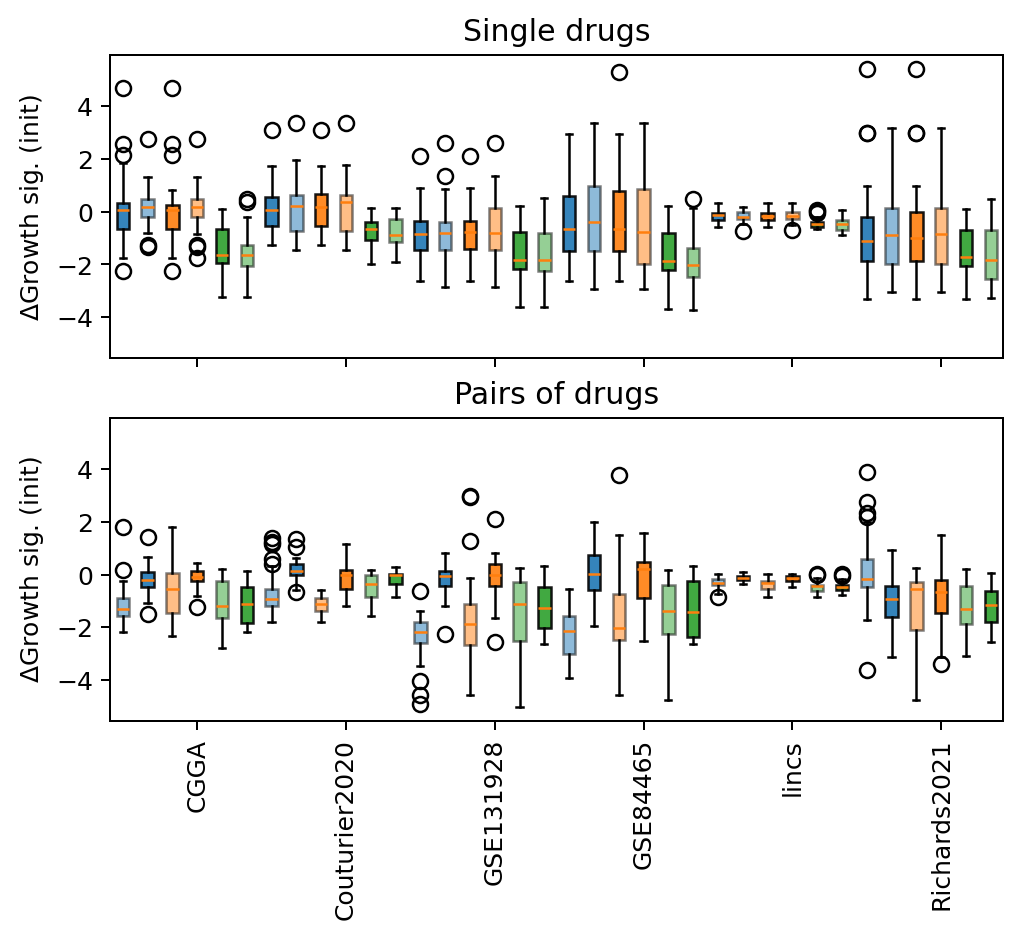

In [288]:
## count the cases:
## 6 studies
## numerous cell lines in each study (these are currently averaged over)
## 3 drug selection methods
## 2 combination strategies (add / nonadd)
## 2 single drug/drug pair
## 3 selections
## relative comparison: selected versus unselected ## makes the most sense for the pair
## absolute values: selected boxplot unselected boxplot ##

## how to structure the plots:

## Plot 1: absolute comparison (use separate boxplots for the sel/unsel for each method) do initial, target, etc.
##         separate into two cases, single and pair
##         need to separate into sets of boxplots with the same color
##         then need to keep track of the x positions for the boxplot

rpg_add_single_trend = {}
rpg_add_pair_trend = {}
rpg_nadd_single_trend = {}
rpg_nadd_pair_trend = {}
cmb_add_single_trend = {}
cmb_add_pair_trend = {}
cmb_nadd_single_trend = {}
cmb_nadd_pair_trend = {}
grow_add_single_trend = {}
grow_add_pair_trend = {}
grow_nadd_single_trend = {}
grow_nadd_pair_trend = {}

for ds in ds_l:
    for ana in ['add','nadd']:
        for sop_str in ['single','pair']:
            for costF in ['0.00','0.79','1.57']:
                if (costF,ana,sop_str) == ('0.00','add','single'):
                    rpg_add_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel() ## all data
                elif (costF,ana,sop_str) == ('0.00','add','pair'):
                    rpg_add_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.00','nadd','single'):
                    rpg_nadd_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.00','nadd','pair'):
                    rpg_nadd_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.79','add','single'):
                    cmb_add_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.79','add','pair'):
                    cmb_add_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.79','nadd','single'):
                    cmb_nadd_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.79','nadd','pair'):
                    cmb_nadd_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('1.57','add','single'):
                    grow_add_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('1.57','add','pair'):
                    grow_add_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('1.57','nadd','single'):
                    grow_nadd_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('1.57','nadd','pair'):
                    grow_nadd_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()
    
fix,ax_arr = plt.subplots(2,1,sharex=True,sharey=True,dpi=180)

for ii,data_d in enumerate([rpg_add_single_trend, rpg_nadd_single_trend, cmb_add_single_trend, 
                            cmb_nadd_single_trend, grow_add_single_trend, grow_nadd_single_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==1  else 0.9
    clr = f'C{ii//2}'
    ax_arr[0].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})

ax_arr[0].set_ylabel(r'$\Delta$Growth sig. (init)')
ax_arr[0].set_title('Single drugs')
for ii,data_d in enumerate([rpg_add_pair_trend, rpg_nadd_pair_trend, cmb_add_pair_trend, 
                            cmb_nadd_pair_trend, grow_add_pair_trend, grow_nadd_pair_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[1].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})
    if ii==0:
        ax_arr[1].set_xticks(xvals)
        ax_arr[1].set_xticklabels(data_d.keys(),rotation=90)

ax_arr[1].set_title('Pairs of drugs')
ax_arr[1].set_ylabel(r'$\Delta$Growth sig. (init)')

ax_arr[1].set_xticks(6*(np.arange(6)+0.5))
ax_arr[1].set_xticklabels(ds_l)

fig.savefig(f'{OUT}/abs_growth_change_init.svg')

#### Boxplots aggregated over datasets

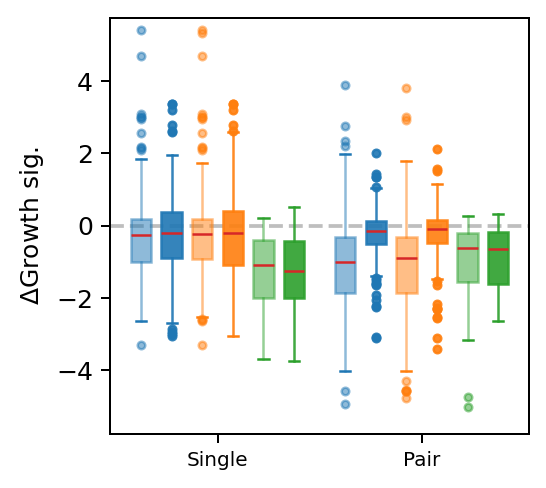

In [319]:
rpg_add_single_trend = []
rpg_add_pair_trend = []
rpg_nadd_single_trend = []
rpg_nadd_pair_trend = []
cmb_add_single_trend = []
cmb_add_pair_trend = []
cmb_nadd_single_trend = []
cmb_nadd_pair_trend = []
grow_add_single_trend = []
grow_add_pair_trend = []
grow_nadd_single_trend = []
grow_nadd_pair_trend = []

for ds in ds_l:
    for ana in ['add','nadd']:
        for sop_str in ['single','pair']:
            for costF in ['0.00','0.79','1.57']:
                if (costF,ana,sop_str) == ('0.00','add','single'):
                    rpg_add_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel()) ## all data
                elif (costF,ana,sop_str) == ('0.00','add','pair'):
                    rpg_add_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.00','nadd','single'):
                    rpg_nadd_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.00','nadd','pair'):
                    rpg_nadd_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','add','single'):
                    cmb_add_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','add','pair'):
                    cmb_add_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','nadd','single'):
                    cmb_nadd_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','nadd','pair'):
                    cmb_nadd_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','add','single'):
                    grow_add_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','add','pair'):
                    grow_add_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','nadd','single'):
                    grow_nadd_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','nadd','pair'):
                    grow_nadd_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
    
fig,ax = plt.subplots(1,1,figsize=(3,3),dpi=180)

ax.boxplot([rpg_add_single_trend,rpg_add_pair_trend],positions=np.arange(2),widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C0','edgecolor':'C0','alpha':0.5},
           flierprops={'markerfacecolor':'C0','markeredgecolor':'C0','marker':'.','alpha':0.5},
           whiskerprops={'color':'C0','alpha':0.5},
           capprops={'color':'C0'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([rpg_nadd_single_trend,rpg_nadd_pair_trend],positions=np.arange(2)+0.15,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C0','edgecolor':'C0','alpha':0.9},
           flierprops={'markerfacecolor':'C0','markeredgecolor':'C0','marker':'.','alpha':0.9},
           whiskerprops={'color':'C0','alpha':0.9},
           capprops={'color':'C0'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([cmb_add_single_trend,cmb_add_pair_trend],positions=np.arange(2)+0.3,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C1','edgecolor':'C1','alpha':0.5},
           flierprops={'markerfacecolor':'C1','markeredgecolor':'C1','marker':'.','alpha':0.5},
           whiskerprops={'color':'C1','alpha':0.5},
           capprops={'color':'C1'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([cmb_nadd_single_trend,cmb_nadd_pair_trend],positions=np.arange(2)+0.45,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C1','edgecolor':'C1','alpha':0.9},
           flierprops={'markerfacecolor':'C1','markeredgecolor':'C1','marker':'.','alpha':0.9},
           whiskerprops={'color':'C1','alpha':0.9},
           capprops={'color':'C1'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([grow_add_single_trend,grow_add_pair_trend],positions=np.arange(2)+0.6,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C2','edgecolor':'C2','alpha':0.5},
           flierprops={'markerfacecolor':'C2','markeredgecolor':'C2','marker':'.','alpha':0.5},
           whiskerprops={'color':'C2','alpha':0.5},
           capprops={'color':'C2'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([grow_nadd_single_trend,grow_nadd_pair_trend],positions=np.arange(2)+0.75,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C2','edgecolor':'C2','alpha':0.9},
           flierprops={'markerfacecolor':'C2','markeredgecolor':'C2','marker':'.','alpha':0.9},
           whiskerprops={'color':'C2','alpha':0.9},
           capprops={'color':'C2'},medianprops={'color':'C3'},zorder=2)

ax.axhline(0,ls='--',color='C7',zorder=1,alpha=0.5)
ax.set_ylabel(r'$\Delta$Growth sig.')
ax.set_xticks([0.375,1.375])
ax.set_xticklabels(['Single','Pair'],size=8)
ax.set_xlim(-.15,1.9)
ax.set_ylim(-5.75,5.75)
fig.savefig(f'{OUT}/figS3c_abs_growth_change_init_agg.svg')

#### Analysis 3: Plot of $\Delta$Growth for the target/healthy state across all datasets and methods

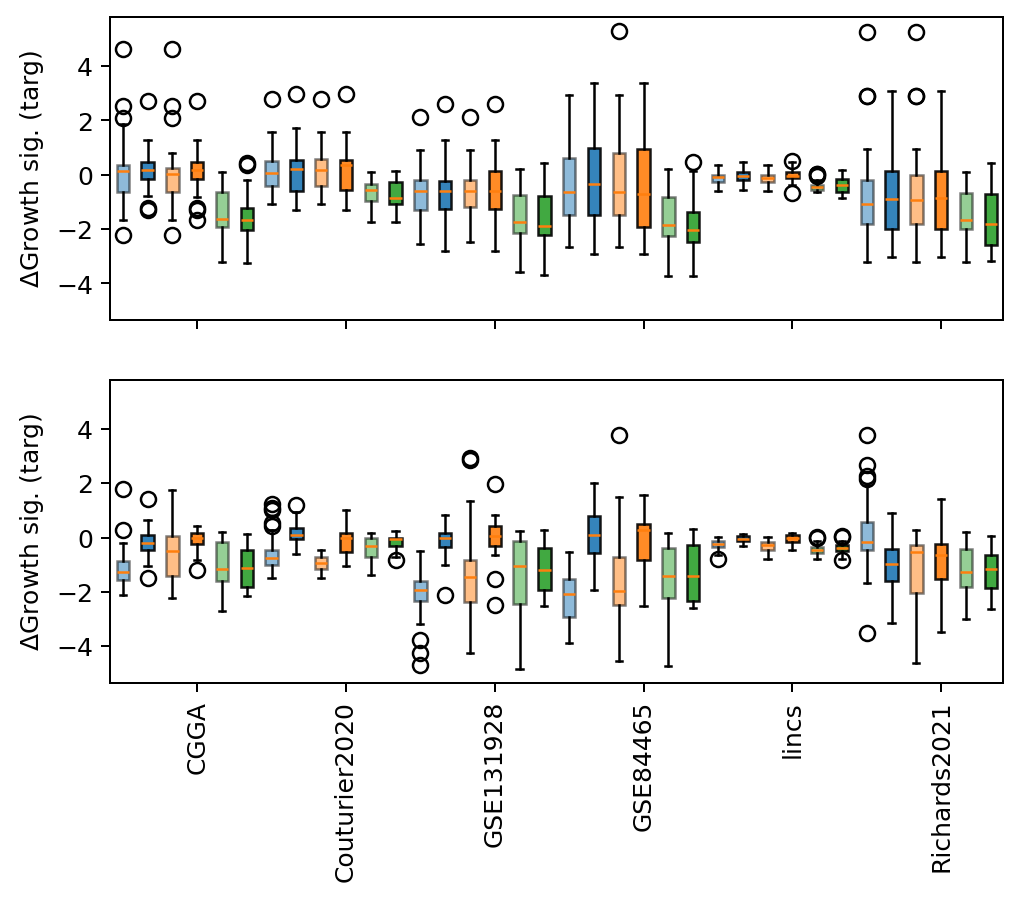

In [289]:
rpg_add_single_trend = {}
rpg_add_pair_trend = {}
rpg_nadd_single_trend = {}
rpg_nadd_pair_trend = {}
cmb_add_single_trend = {}
cmb_add_pair_trend = {}
cmb_nadd_single_trend = {}
cmb_nadd_pair_trend = {}
grow_add_single_trend = {}
grow_add_pair_trend = {}
grow_nadd_single_trend = {}
grow_nadd_pair_trend = {}

for ds in ds_l:
    for ana in ['add','nadd']:
        for sop_str in ['single','pair']:
            for costF in ['0.00','0.79','1.57']:
                if (costF,ana,sop_str) == ('0.00','add','single'):
                    rpg_add_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.00','add','pair'):
                    rpg_add_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.00','nadd','single'):
                    rpg_nadd_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.00','nadd','pair'):
                    rpg_nadd_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.79','add','single'):
                    cmb_add_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.79','add','pair'):
                    cmb_add_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.79','nadd','single'):
                    cmb_nadd_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('0.79','nadd','pair'):
                    cmb_nadd_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('1.57','add','single'):
                    grow_add_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('1.57','add','pair'):
                    grow_add_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('1.57','nadd','single'):
                    grow_nadd_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
                elif (costF,ana,sop_str) == ('1.57','nadd','pair'):
                    grow_nadd_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()
    
fix,ax_arr = plt.subplots(2,1,sharex=True,sharey=True,dpi=180)

for ii,data_d in enumerate([rpg_add_single_trend, rpg_nadd_single_trend, cmb_add_single_trend, 
                            cmb_nadd_single_trend, grow_add_single_trend, grow_nadd_single_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[0].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})

ax_arr[0].set_ylabel(r'$\Delta$Growth sig. (targ)')

for ii,data_d in enumerate([rpg_add_pair_trend, rpg_nadd_pair_trend, cmb_add_pair_trend, 
                            cmb_nadd_pair_trend, grow_add_pair_trend, grow_nadd_pair_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[1].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})
    if ii==0:
        ax_arr[1].set_xticks(xvals)
        ax_arr[1].set_xticklabels(data_d.keys(),rotation=90)

ax_arr[1].set_ylabel(r'$\Delta$Growth sig. (targ)')
ax_arr[1].set_xticks(6*(np.arange(6)+0.5))
ax_arr[1].set_xticklabels(ds_l)

fig.savefig(f'{OUT}/abs_growth_change_targ.svg')

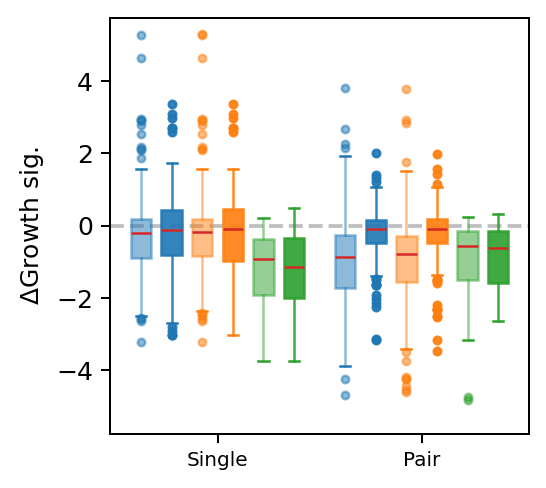

In [320]:
rpg_add_single_trend = []
rpg_add_pair_trend = []
rpg_nadd_single_trend = []
rpg_nadd_pair_trend = []
cmb_add_single_trend = []
cmb_add_pair_trend = []
cmb_nadd_single_trend = []
cmb_nadd_pair_trend = []
grow_add_single_trend = []
grow_add_pair_trend = []
grow_nadd_single_trend = []
grow_nadd_pair_trend = []

for ds in ds_l:
    for ana in ['add','nadd']:
        for sop_str in ['single','pair']:
            for costF in ['0.00','0.79','1.57']:
                if (costF,ana,sop_str) == ('0.00','add','single'):
                    rpg_add_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel()) ## all data
                elif (costF,ana,sop_str) == ('0.00','add','pair'):
                    rpg_add_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.00','nadd','single'):
                    rpg_nadd_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.00','nadd','pair'):
                    rpg_nadd_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','add','single'):
                    cmb_add_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','add','pair'):
                    cmb_add_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','nadd','single'):
                    cmb_nadd_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','nadd','pair'):
                    cmb_nadd_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','add','single'):
                    grow_add_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','add','pair'):
                    grow_add_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','nadd','single'):
                    grow_nadd_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','nadd','pair'):
                    grow_nadd_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel())
    
fig,ax = plt.subplots(1,1,figsize=(3,3),dpi=180)

ax.boxplot([rpg_add_single_trend,rpg_add_pair_trend],positions=np.arange(2),widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C0','edgecolor':'C0','alpha':0.5},
           flierprops={'markerfacecolor':'C0','markeredgecolor':'C0','marker':'.','alpha':0.5},
           whiskerprops={'color':'C0','alpha':0.5},
           capprops={'color':'C0'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([rpg_nadd_single_trend,rpg_nadd_pair_trend],positions=np.arange(2)+0.15,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C0','edgecolor':'C0','alpha':0.9},
           flierprops={'markerfacecolor':'C0','markeredgecolor':'C0','marker':'.','alpha':0.9},
           whiskerprops={'color':'C0','alpha':0.9},
           capprops={'color':'C0'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([cmb_add_single_trend,cmb_add_pair_trend],positions=np.arange(2)+0.3,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C1','edgecolor':'C1','alpha':0.5},
           flierprops={'markerfacecolor':'C1','markeredgecolor':'C1','marker':'.','alpha':0.5},
           whiskerprops={'color':'C1','alpha':0.5},
           capprops={'color':'C1'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([cmb_nadd_single_trend,cmb_nadd_pair_trend],positions=np.arange(2)+0.45,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C1','edgecolor':'C1','alpha':0.9},
           flierprops={'markerfacecolor':'C1','markeredgecolor':'C1','marker':'.','alpha':0.9},
           whiskerprops={'color':'C1','alpha':0.9},
           capprops={'color':'C1'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([grow_add_single_trend,grow_add_pair_trend],positions=np.arange(2)+0.6,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C2','edgecolor':'C2','alpha':0.5},
           flierprops={'markerfacecolor':'C2','markeredgecolor':'C2','marker':'.','alpha':0.5},
           whiskerprops={'color':'C2','alpha':0.5},
           capprops={'color':'C2'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([grow_nadd_single_trend,grow_nadd_pair_trend],positions=np.arange(2)+0.75,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C2','edgecolor':'C2','alpha':0.9},
           flierprops={'markerfacecolor':'C2','markeredgecolor':'C2','marker':'.','alpha':0.9},
           whiskerprops={'color':'C2','alpha':0.9},
           capprops={'color':'C2'},medianprops={'color':'C3'},zorder=2)

ax.axhline(0,ls='--',color='C7',zorder=1,alpha=0.5)
ax.set_ylabel(r'$\Delta$Growth sig.')
ax.set_xticks([0.375,1.375])
ax.set_xlim(-.15,1.9)
ax.set_ylim(-5.75,5.75)
ax.set_xticklabels(['Single','Pair'],size=8)

fig.savefig(f'{OUT}/figS3d_abs_growth_change_targ_agg.svg')

#### Pairwise analysis

[Text(3.0, 0, 'CGGA'),
 Text(9.0, 0, 'Couturier2020'),
 Text(15.0, 0, 'GSE131928'),
 Text(21.0, 0, 'GSE84465'),
 Text(27.0, 0, 'lincs'),
 Text(33.0, 0, 'Richards2021')]

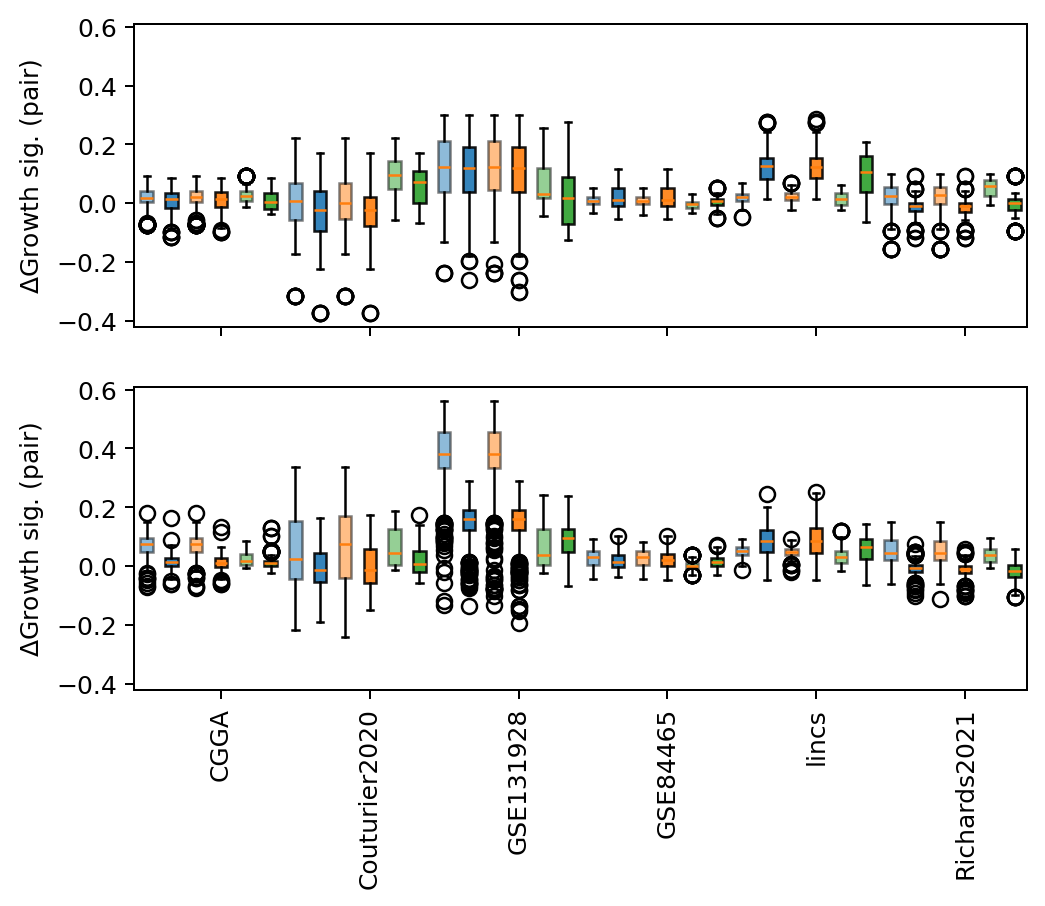

In [244]:
## Need to concatentate the pairwise data for absolute values will have a differences for the paired data..


rpg_add_single_trend = {}
rpg_add_pair_trend = {}
rpg_nadd_single_trend = {}
rpg_nadd_pair_trend = {}
cmb_add_single_trend = {}
cmb_add_pair_trend = {}
cmb_nadd_single_trend = {}
cmb_nadd_pair_trend = {}
grow_add_single_trend = {}
grow_add_pair_trend = {}
grow_nadd_single_trend = {}
grow_nadd_pair_trend = {}

for ds in ds_l:
    for ana in ['add','nadd']:
        for sop_str in ['single','pair']:
            for costF in ['0.00','0.79','1.57']:
                if (costF,ana,sop_str) == ('0.00','add','single'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    rpg_add_single_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('0.00','add','pair'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    rpg_add_pair_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('0.00','nadd','single'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    rpg_nadd_single_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('0.00','nadd','pair'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    rpg_nadd_pair_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('0.79','add','single'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    cmb_add_single_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('0.79','add','pair'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    cmb_add_pair_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('0.79','nadd','single'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    cmb_nadd_single_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('0.79','nadd','pair'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    cmb_nadd_pair_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('1.57','add','single'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    grow_add_single_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('1.57','add','pair'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    grow_add_pair_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('1.57','nadd','single'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    grow_nadd_single_trend[ds] = all_dtox_vals
                elif (costF,ana,sop_str) == ('1.57','nadd','pair'):
                    all_dtox_vals = []
                    for dtox_vals in delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')]: ## this is a list of effects
                        all_dtox_vals.extend(dtox_vals.values)
                    grow_nadd_pair_trend[ds] = all_dtox_vals
    
fix,ax_arr = plt.subplots(2,1,sharex=True,sharey=True,dpi=180)

for ii,data_d in enumerate([rpg_add_single_trend, rpg_nadd_single_trend, cmb_add_single_trend, 
                            cmb_nadd_single_trend, grow_add_single_trend, grow_nadd_single_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[0].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})

ax_arr[0].set_ylabel(r'$\Delta$Growth sig. (paired)')

for ii,data_d in enumerate([rpg_add_pair_trend, rpg_nadd_pair_trend, cmb_add_pair_trend, 
                            cmb_nadd_pair_trend, grow_add_pair_trend, grow_nadd_pair_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[1].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})
    if ii==0:
        ax_arr[1].set_xticks(xvals)
        ax_arr[1].set_xticklabels(data_d.keys(),rotation=90)

ax_arr[1].set_ylabel(r'$\Delta$Growth sig. (paired)')

ax_arr[1].set_xticks(6*(np.arange(6)+0.5))
ax_arr[1].set_xticklabels(ds_l)

fig.savefig(f'{OUT}/abs_growth_change_paired.svg')

### Fig. S3e: Relative analysis between selected vs. unselected drugs

#### Comparing the difference in target and initial states of the selected drugs versus the unselected drugs

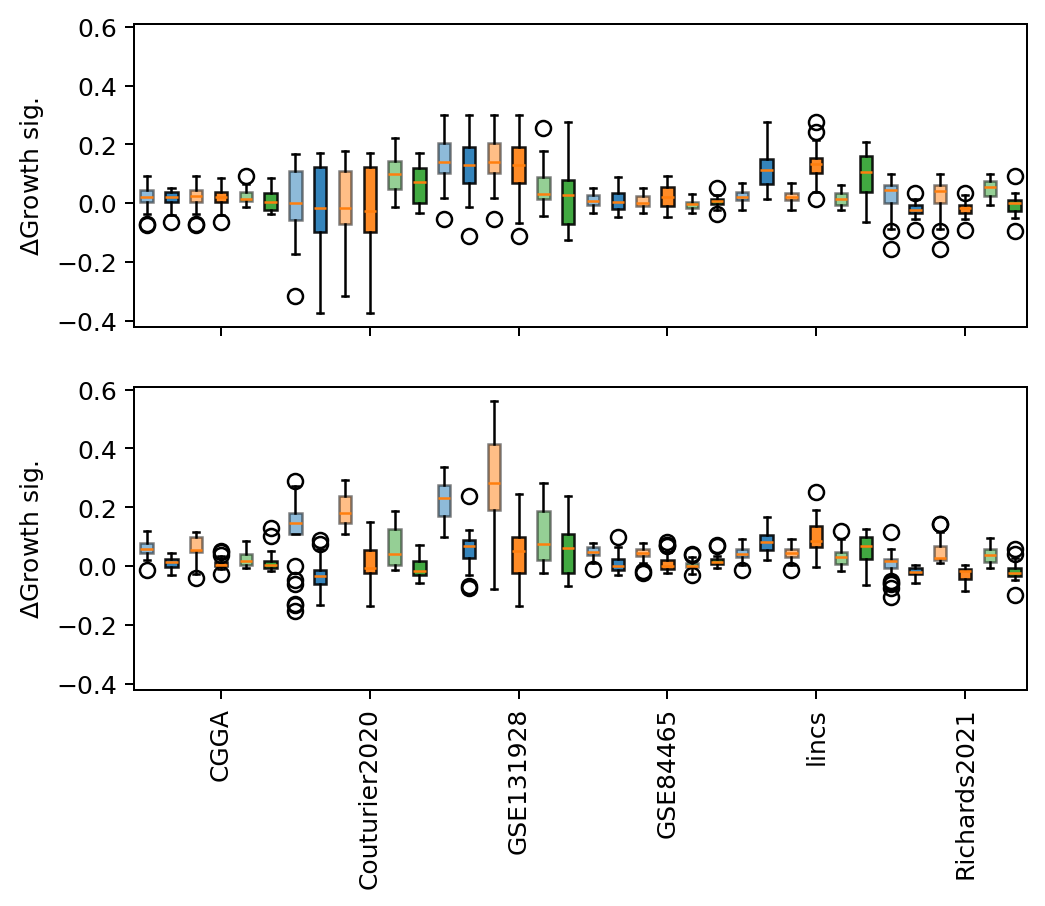

In [290]:
## count the cases:
## 6 studies
## numerous cell lines in each study (these are currently averaged over)
## 3 drug selection methods
## 2 combination strategies (add / nonadd)
## 2 single drug/drug pair
## 3 selections
## relative comparison: selected versus unselected ## makes the most sense for the pair
## absolute values: selected boxplot unselected boxplot ##

## how to structure the plots:

## Plot 1: absolute comparison (use separate boxplots for the sel/unsel for each method) do initial, target, etc.
##         separate into two cases, single and pair
##         need to separate into sets of boxplots with the same color
##         then need to keep track of the x positions for the boxplot

rpg_add_single_trend = {}
rpg_add_pair_trend = {}
rpg_nadd_single_trend = {}
rpg_nadd_pair_trend = {}
cmb_add_single_trend = {}
cmb_add_pair_trend = {}
cmb_nadd_single_trend = {}
cmb_nadd_pair_trend = {}
grow_add_single_trend = {}
grow_add_pair_trend = {}
grow_nadd_single_trend = {}
grow_nadd_pair_trend = {}

for ds in ds_l:
    for ana in ['add','nadd']:
        for sop_str in ['single','pair']:
            for costF in ['0.00','0.79','1.57']:
                if (costF,ana,sop_str) == ('0.00','add','single'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    rpg_add_single_trend[ds] =  selected# - baseline
                    ## all data
                elif (costF,ana,sop_str) == ('0.00','add','pair'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    rpg_add_pair_trend[ds] =  selected# - baseline
                elif (costF,ana,sop_str) == ('0.00','nadd','single'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    rpg_nadd_single_trend[ds] =  selected# - baseline
                elif (costF,ana,sop_str) == ('0.00','nadd','pair'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    rpg_nadd_pair_trend[ds] =  selected# - baseline
                elif (costF,ana,sop_str) == ('0.79','add','single'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    cmb_add_single_trend[ds] =  selected# - baseline
                elif (costF,ana,sop_str) == ('0.79','add','pair'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    cmb_add_pair_trend[ds] =  selected# - baseline
                elif (costF,ana,sop_str) == ('0.79','nadd','single'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    cmb_nadd_single_trend[ds] =  selected# - baseline
                elif (costF,ana,sop_str) == ('0.79','nadd','pair'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    cmb_nadd_pair_trend[ds] =  selected# - baseline
                elif (costF,ana,sop_str) == ('1.57','add','single'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    grow_add_single_trend[ds] =  selected# - baseline
                elif (costF,ana,sop_str) == ('1.57','add','pair'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    grow_add_pair_trend[ds] =  selected# - baseline
                elif (costF,ana,sop_str) == ('1.57','nadd','single'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    grow_nadd_single_trend[ds] =  selected# - baseline
                elif (costF,ana,sop_str) == ('1.57','nadd','pair'):
                    selected = (delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    #baseline = np.median((delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')]- delta_tox_d[(ds,ana,sop_str,costF,'init_unsel')]).values.ravel())
                    grow_nadd_pair_trend[ds] =  selected# - baseline
                     
    
fix,ax_arr = plt.subplots(2,1,sharex=True,sharey=True,dpi=180)

for ii,data_d in enumerate([rpg_add_single_trend, rpg_nadd_single_trend, cmb_add_single_trend, 
                            cmb_nadd_single_trend, grow_add_single_trend, grow_nadd_single_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[0].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})

ax_arr[0].set_ylabel(r'$\Delta$Growth sig.')

for ii,data_d in enumerate([rpg_add_pair_trend, rpg_nadd_pair_trend, cmb_add_pair_trend, 
                            cmb_nadd_pair_trend, grow_add_pair_trend, grow_nadd_pair_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[1].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})
    if ii==0:
        ax_arr[1].set_xticks(xvals)
        ax_arr[1].set_xticklabels(data_d.keys(),rotation=90)

ax_arr[1].set_ylabel(r'$\Delta$Growth sig.')

ax_arr[1].set_xticks(6*(np.arange(6)+0.5))
ax_arr[1].set_xticklabels(ds_l)

fig.savefig(f'{OUT}/rel_growth_change_targminusinit.svg')

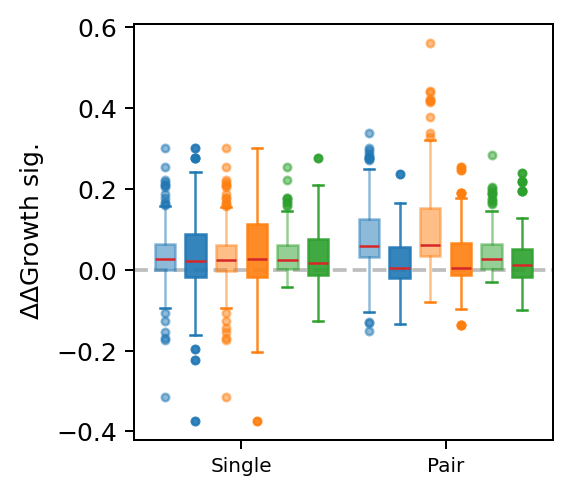

In [321]:
rpg_add_single_trend = []
rpg_add_pair_trend = []
rpg_nadd_single_trend = []
rpg_nadd_pair_trend = []
cmb_add_single_trend = []
cmb_add_pair_trend = []
cmb_nadd_single_trend = []
cmb_nadd_pair_trend = []
grow_add_single_trend = []
grow_add_pair_trend = []
grow_nadd_single_trend = []
grow_nadd_pair_trend = []

for ds in ds_l:
    for ana in ['add','nadd']:
        for sop_str in ['single','pair']:
            for costF in ['0.00','0.79','1.57']:
                if (costF,ana,sop_str) == ('0.00','add','single'):
                    rpg_add_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.00','add','pair'):
                    rpg_add_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.00','nadd','single'):
                    rpg_nadd_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.00','nadd','pair'):
                    rpg_nadd_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','add','single'):
                    cmb_add_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','add','pair'):
                    cmb_add_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','nadd','single'):
                    cmb_nadd_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','nadd','pair'):
                    cmb_nadd_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())                                    
                elif (costF,ana,sop_str) == ('1.57','add','single'):
                    grow_add_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','add','pair'):
                    grow_add_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','nadd','single'):
                    grow_nadd_single_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','nadd','pair'):
                    grow_nadd_pair_trend.extend(delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - delta_tox_d[(ds,ana,sop_str,costF,'init_sel')].values.ravel())
                    
                     
    
fig,ax = plt.subplots(1,1,figsize=(3,3),dpi=180)

ax.boxplot([rpg_add_single_trend,rpg_add_pair_trend],positions=np.arange(2),widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C0','edgecolor':'C0','alpha':0.5},
           flierprops={'markerfacecolor':'C0','markeredgecolor':'C0','marker':'.','alpha':0.5},
           whiskerprops={'color':'C0','alpha':0.5},
           capprops={'color':'C0'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([rpg_nadd_single_trend,rpg_nadd_pair_trend],positions=np.arange(2)+0.15,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C0','edgecolor':'C0','alpha':0.9},
           flierprops={'markerfacecolor':'C0','markeredgecolor':'C0','marker':'.','alpha':0.9},
           whiskerprops={'color':'C0','alpha':0.9},
           capprops={'color':'C0'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([cmb_add_single_trend,cmb_add_pair_trend],positions=np.arange(2)+0.3,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C1','edgecolor':'C1','alpha':0.5},
           flierprops={'markerfacecolor':'C1','markeredgecolor':'C1','marker':'.','alpha':0.5},
           whiskerprops={'color':'C1','alpha':0.5},
           capprops={'color':'C1'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([cmb_nadd_single_trend,cmb_nadd_pair_trend],positions=np.arange(2)+0.45,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C1','edgecolor':'C1','alpha':0.9},
           flierprops={'markerfacecolor':'C1','markeredgecolor':'C1','marker':'.','alpha':0.9},
           whiskerprops={'color':'C1','alpha':0.9},
           capprops={'color':'C1'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([grow_add_single_trend,grow_add_pair_trend],positions=np.arange(2)+0.6,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C2','edgecolor':'C2','alpha':0.5},
           flierprops={'markerfacecolor':'C2','markeredgecolor':'C2','marker':'.','alpha':0.5},
           whiskerprops={'color':'C2','alpha':0.5},
           capprops={'color':'C2'},medianprops={'color':'C3'},zorder=2)

ax.boxplot([grow_nadd_single_trend,grow_nadd_pair_trend],positions=np.arange(2)+0.75,widths=0.1,
           patch_artist=True,boxprops={'facecolor':'C2','edgecolor':'C2','alpha':0.9},
           flierprops={'markerfacecolor':'C2','markeredgecolor':'C2','marker':'.','alpha':0.9},
           whiskerprops={'color':'C2','alpha':0.9},
           capprops={'color':'C2'},medianprops={'color':'C3'},zorder=2)

ax.axhline(0,ls='--',color='C7',zorder=1,alpha=0.5)
ax.set_ylabel(r'$\Delta\Delta$Growth sig.')
ax.set_xticks([0.375,1.375])
ax.set_xlim(-.15,1.9)
#ax.set_ylim(-5.75,5.75)
ax.set_xticklabels(['Single','Pair'],size=8)

fig.savefig(f'{OUT}/figS3e_rel_growth_change_targminusinit_agg.svg')

#### Paired differences versus unselected cases

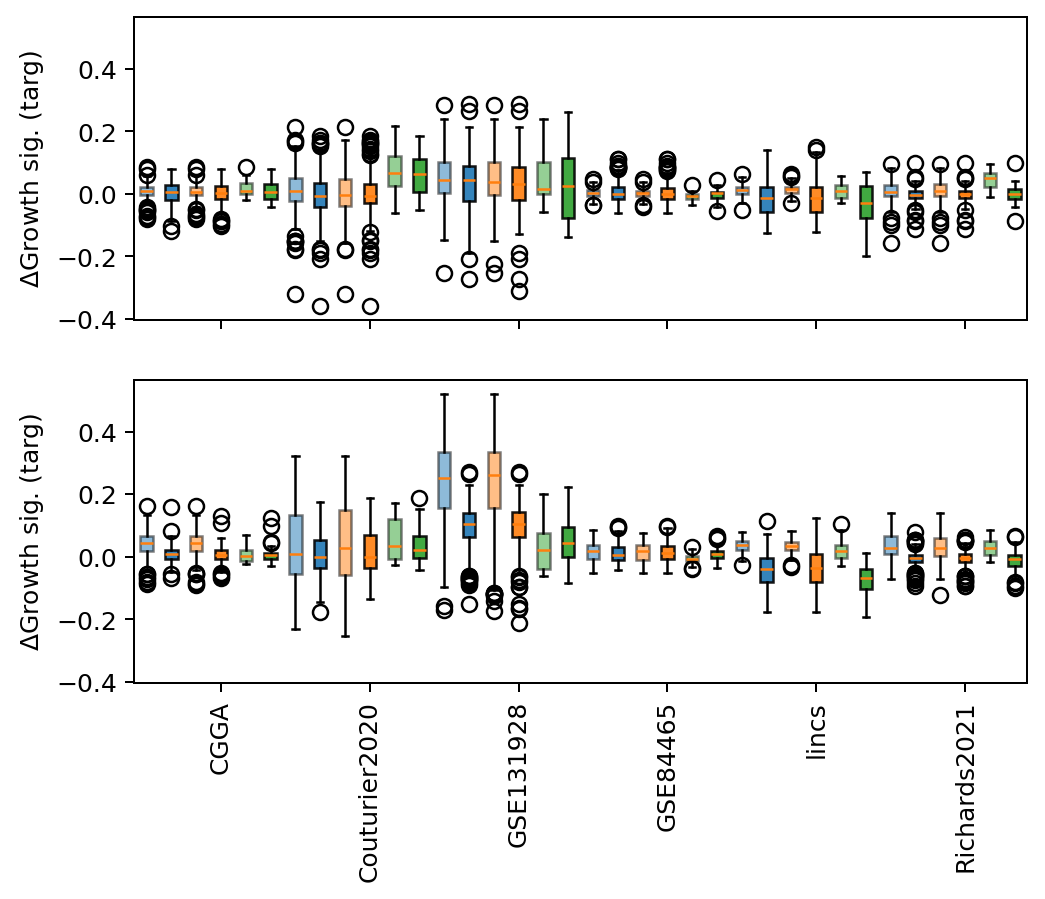

In [247]:
rpg_add_single_trend = {}
rpg_add_pair_trend = {}
rpg_nadd_single_trend = {}
rpg_nadd_pair_trend = {}
cmb_add_single_trend = {}
cmb_add_pair_trend = {}
cmb_nadd_single_trend = {}
cmb_nadd_pair_trend = {}
grow_add_single_trend = {}
grow_add_pair_trend = {}
grow_nadd_single_trend = {}
grow_nadd_pair_trend = {}

for ds in ds_l:
    for ana in ['add','nadd']:
        for sop_str in ['single','pair']:
            for costF in ['0.00','0.79','1.57']:
                if (costF,ana,sop_str) == ('0.00','add','single'):
                    rpg_add_single_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('0.00','add','pair'):
                    rpg_add_pair_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('0.00','nadd','single'):
                    rpg_nadd_single_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('0.00','nadd','pair'):
                    rpg_nadd_pair_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('0.79','add','single'):
                    cmb_add_single_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('0.79','add','pair'):
                    cmb_add_pair_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('0.79','nadd','single'):
                    cmb_nadd_single_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('0.79','nadd','pair'):
                    cmb_nadd_pair_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('1.57','add','single'):
                    grow_add_single_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('1.57','add','pair'):
                    grow_add_pair_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('1.57','nadd','single'):
                    grow_nadd_single_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
                elif (costF,ana,sop_str) == ('1.57','nadd','pair'):
                    grow_nadd_pair_trend[ds] = pd.concat([L1-np.median(L2) for L1,L2 in zip(delta_tox_d[(ds,ana,sop_str,costF,'pair_sel')],delta_tox_d[(ds,ana,sop_str,costF,'pair_unsel')])],axis=1).mean(axis=1).values.ravel()
    
fix,ax_arr = plt.subplots(2,1,sharex=True,sharey=True,dpi=180)

for ii,data_d in enumerate([rpg_add_single_trend, rpg_nadd_single_trend, cmb_add_single_trend, 
                            cmb_nadd_single_trend, grow_add_single_trend, grow_nadd_single_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[0].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})

ax_arr[0].set_ylabel(r'$\Delta$Growth sig. (paired)')

for ii,data_d in enumerate([rpg_add_pair_trend, rpg_nadd_pair_trend, cmb_add_pair_trend, 
                            cmb_nadd_pair_trend, grow_add_pair_trend, grow_nadd_pair_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[1].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})
    if ii==0:
        ax_arr[1].set_xticks(xvals)
        ax_arr[1].set_xticklabels(data_d.keys(),rotation=90)

ax_arr[1].set_ylabel(r'$\Delta$Growth sig. (paired)')
ax_arr[1].set_xticks(6*(np.arange(6)+0.5))
ax_arr[1].set_xticklabels(ds_l)

fig.savefig(f'{OUT}/rel_growth_change_paired.svg')

In [ ]:
rpg_add_single_trend = {}
rpg_add_pair_trend = {}
rpg_nadd_single_trend = {}
rpg_nadd_pair_trend = {}
cmb_add_single_trend = {}
cmb_add_pair_trend = {}
cmb_nadd_single_trend = {}
cmb_nadd_pair_trend = {}
grow_add_single_trend = {}
grow_add_pair_trend = {}
grow_nadd_single_trend = {}
grow_nadd_pair_trend = {}

for ds in ds_l[:2]:
    for ana in ['add','nadd']:
        for sop_str in ['single','pair']:
            for costF in ['0.00','0.79','1.57']:
                if (costF,ana,sop_str) == ('0.00','add','single'):
                    rpg_add_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.00','add','pair'):
                    rpg_add_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.00','nadd','single'):
                    rpg_nadd_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.00','nadd','pair'):
                    rpg_nadd_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','add','single'):
                    cmb_add_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','add','pair'):
                    cmb_add_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','nadd','single'):
                    cmb_nadd_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('0.79','nadd','pair'):
                    cmb_nadd_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','add','single'):
                    grow_add_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','add','pair'):
                    grow_add_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','nadd','single'):
                    grow_nadd_single_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
                elif (costF,ana,sop_str) == ('1.57','nadd','pair'):
                    grow_nadd_pair_trend[ds] = delta_tox_d[(ds,ana,sop_str,costF,'targ_sel')].values.ravel() - np.median(delta_tox_d[(ds,ana,sop_str,costF,'targ_unsel')].values.ravel())
    
fix,ax_arr = plt.subplots(2,1,sharex=True,sharey=True,dpi=180)

for ii,data_d in enumerate([rpg_add_single_trend, rpg_nadd_single_trend, cmb_add_single_trend, 
                            cmb_nadd_single_trend, grow_add_single_trend, grow_nadd_single_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[0].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})

ax_arr[0].set_ylabel(r'$\Delta$Growth sig. (targ)')

for ii,data_d in enumerate([rpg_add_pair_trend, rpg_nadd_pair_trend, cmb_add_pair_trend, 
                            cmb_nadd_pair_trend, grow_add_pair_trend, grow_nadd_pair_trend,]):
    xvals = ii+6*np.arange(len(data_d.keys()))
    al = 0.5 if (ii % 2)==0  else 0.9
    clr = f'C{ii//2}'
    ax_arr[1].boxplot(data_d.values(),positions=xvals,patch_artist=True,boxprops={'facecolor':clr,'alpha':al})
    if ii==0:
        ax_arr[1].set_xticks(xvals)
        ax_arr[1].set_xticklabels(data_d.keys(),rotation=90)

ax_arr[1].set_ylabel(r'$\Delta$Growth sig. (targ)')
ax_arr[1].set_xticks(6*(np.arange(6)+0.5))
ax_arr[1].set_xticklabels(ds_l)

fig.savefig(f'{OUT}/rel_growth_change_targ.svg')

## Additional analysis: compute `growth_signature_viability_stats.pkl` and `growth_signature_selected_v_unselected.pkl`

The following code relies on the "avg-dtox-pair" files, which can be computed via `analyze_toxicity_results.py`

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from scipy.stats import percentileofscore, spearmanr
from glob import glob
nadd_pred_d = pd.read_pickle(f'{IN}/gse_obj_gsm_dp_d_0522_nonadd_v2.pkl')
add_pred_d = pd.read_pickle(f'{IN}/gse_obj_gsm_dp_d_0522_linear_v2.pkl')
## measured drugs
mv_res = pd.read_pickle(f'{IN}/median_viability_results.pkl')
cl_abbr_l = ['43','CH','Io','LN']
ds_l = ['lincs', 'Richards2021', 'Couturier2020', 'GSE84465', 'CGGA',  'GSE131928']


op_d = {} ## compares the predictions vs. the toxicity
op_d2 = {} ## compares the toxicity with the assays
#state_avg_tox = {}
drg_avg_tox_single = {}
drg_avg_tox_pair = {}
single_box_data = {}
pair_box_data = {}
lowcorr_pairs_d = {} ## examines cases where the individual differences appear
for ds in ds_l:
    print(ds)
    if ds.startswith('GSE'):
        ds_key=ds+'_2'
    else:
        ds_key=ds    
    for ana_str in ['add','nadd']:
        print(ana_str)
        if ana_str=='add':
            mpred_ser = pd.Series(add_pred_d[ds_key])
        else:
            mpred_ser = pd.Series(nadd_pred_d[ds_key])
        for sop_str in ['single','pair']:
            ## if single, the comparison needs to sum over all pairs that include a drug
            avg_dtox_l = glob(f'{TOX}/{ds}/*__avg-dtox-{sop_str}-{ana_str}.pkl') ## can we avoid including?
            for adfn in avg_dtox_l:
                csn = adfn.split('/')[-1].split('__')[0] ## this is the experiment identifier
                ad_df = pd.read_pickle(adfn)
                CC = ad_df.corr() ## correlations between the impact of the drugs on each state
                drg_avg = ad_df.mean(axis=1) ## average over all states
                if sop_str=='single':
                    drg_avg_tox_single[(ds,ana_str,csn)]=drg_avg ## store in the single 
                else:
                    drg_avg_tox_pair[(ds,ana_str,csn)]=drg_avg
                ## look at the dosages of both drugs and separate the lists               
                if sop_str=='single':
                    TOX_NM_2_COM = toxicity_drug_2_names(ad_df)
                    EXP_NM_2_COM, exp_tox_dat = experimental_drug_2_names_single(mv_res,TOX_NM_2_COM,ad_df.mean(axis=1))
                    low_dose = exp_tox_dat[((exp_tox_dat.drug1_uM!=10))]
                    ten_uM = exp_tox_dat[(exp_tox_dat.drug1_uM==10)]
                else:
                    TOX_NM_2_COM = toxicity_drug_2_names_pairs(ad_df)
                    EXP_NM_2_COM, exp_tox_dat = experimental_drug_2_names_pairs(mv_res,TOX_NM_2_COM,ad_df.mean(axis=1))
                    low_dose = exp_tox_dat[((exp_tox_dat.drug1_uM!=10)|(exp_tox_dat.drug2_uM!=10))]
                    ten_uM = exp_tox_dat[((exp_tox_dat.drug1_uM==10)&(exp_tox_dat.drug2_uM==10))]
                via_data = ten_uM
                via_data2 = low_dose
                for met in ['alt_obj_kernel_0221']:
                    XXX = np.vstack([via_data.loc[:,f'pred_tox_{met}'].values.reshape(-1,1),
                                     via_data2.loc[:,f'pred_tox_{met}'].values.reshape(-1,1)])
                    scrs = np.hstack([via_data.loc[:,f'pred_tox_{met}'].values*-1,
                                      via_data2.loc[:,f'pred_tox_{met}'].values*-1,])
                    med_via_data = via_data.iloc[:,4:8].median(axis=1)
                    yyy1 = (med_via_data<0.1).astype(float).values ## 0.1 is between the 50th and 75th percentiles for all cell lines
                    yyy2 = np.ones(via_data2.shape[0])
                    yyy = np.hstack([yyy1,yyy2])
                    low_dose
                    if np.mean(yyy)==1 or np.mean(yyy)==0:
                        print(f'Changing threshold to median: {ds} {sop_str} {csn} {via_cl} median')
                        yyy = (sel_via_data<sel_via_data.median()).astype(float).values
                    ## perform *overall* logistic regression to estimate scores
                    clf = LogisticRegression(solver="liblinear", random_state=0, fit_intercept=True).fit(XXX, yyy)
                    rocauc = roc_auc_score(yyy,clf.decision_function(XXX))
                    op_d2[(ds,ana_str,sop_str,csn,'median','rocauc')]=rocauc                        
                ## find pairs of states with low correlation
                if CC.shape[0]>1:
                    TRIU_INDS = np.triu_indices(CC.shape[0],k=1)
                    min_CC = np.amin(CC.values[TRIU_INDS])
                    if min_CC < 0.99: ## find the profile!
                        bbb = np.where(CC.values[TRIU_INDS]<0.99)
                        lowcorr_pairs = zip(CC.columns[TRIU_INDS[0][bbb]],CC.columns[TRIU_INDS[1][bbb]]) ## not sure how to store the columns
                        lowcorr_pairs_d[(ds,ana_str,sop_str,csn)] = list(lowcorr_pairs)
                for costF in ['0.00','0.79','1.57']:
                    try:
                        if ana_str=='nadd' and ds=='lincs':
                            state_int = int(STATES[STATES.state_name==csn].index[0])-18
                            SEL = mpred_ser.xs((costF,state_int),level=[0,1])
                        else:
                            SEL = mpred_ser.xs((costF,csn),level=[0,1])
                    except KeyError:
                        continue
                    if ana_str == 'add':
                        SEL = SEL[~SEL.isna()].droplevel(0)
                    elif ana_str=='nadd':
                        SEL = SEL[~SEL.isna()].droplevel([0,1,2])
                    nm2com = optimized_drug_2_names(SEL)
                    if sop_str=='single':
                        ranksum_ser = single_drug_ranksum(SEL,nm2com)
                        IS = ranksum_ser.index.intersection(drg_avg.index)
                        qt=0.5
                        yyy = (drg_avg.loc[IS]<drg_avg.quantile(qt))
                        vibs = ranksum_ser.loc[IS]
                        while np.mean(yyy)==1 or np.mean(yyy)==0:
                            if np.mean(yyy)==1:
                                qt -= qt/2.
                            else:
                                qt += qt/2.
                            #print(f'Changing threshold to {qt:.3f}: {ds} {sop_str} {csn} {via_cl} {cl_abbr}')
                            yyy = (drg_avg.loc[IS]<drg_avg.quantile(qt))
                        clf = LogisticRegression(solver="liblinear", random_state=0, fit_intercept=True).fit(vibs.values.reshape(-1,1), yyy)
                        scrs = clf.decision_function(vibs.values.reshape(-1,1))
                        ## percentile
                        PT = percentileofscore(drg_avg.values,drg_avg.loc[IS])
                        single_box_data[(ds,ana_str,csn,costF)] = pd.Series(PT,index=IS)
                        op_d[(ds,ana_str,sop_str,csn,costF,'logPT_mean')] = np.mean(np.log10(PT))
                        op_d[(ds,ana_str,sop_str,csn,costF,'rocauc')] = roc_auc_score(yyy,scrs)
                        ## weighted by rank
                        op_d[(ds,ana_str,sop_str,csn,costF,'logPT_wt')] = np.sum(ranksum_ser.loc[IS]*np.log10(PT))/np.sum(ranksum_ser.loc[IS])
                    else:
                        pair_sel = pair_drug_ranksum(SEL,nm2com)
                        IS = pair_sel.index.intersection(drg_avg.index)
                        qt=0.5
                        yyy = (drg_avg.loc[IS]<drg_avg.quantile(qt))
                        vibs = pair_sel.loc[yyy.index]
                        while np.mean(yyy)==1 or np.mean(yyy)==0:
                            if np.mean(yyy)==1:
                                qt -= qt/2.
                            else:
                                qt += qt/2.
                            yyy = (drg_avg.loc[IS]<drg_avg.quantile(qt))
                        clf = LogisticRegression(solver="liblinear", random_state=0, fit_intercept=True).fit(vibs.values.reshape(-1,1), yyy)
                        scrs = clf.decision_function(vibs.values.reshape(-1,1))
                        op_d[(ds,ana_str,sop_str,csn,costF,'SCC')] = spearmanr(pair_sel.loc[IS],drg_avg.loc[IS])[0]
                        ## percentile
                        PT = percentileofscore(drg_avg.values,drg_avg.loc[IS])
                        pair_box_data[(ds,ana_str,csn,costF)] = pd.Series(PT,index=IS)
                        op_d[(ds,ana_str,sop_str,csn,costF,'logPT_mean')] = np.mean(np.log10(PT))
                        op_d[(ds,ana_str,sop_str,csn,costF,'rocauc')] = roc_auc_score(yyy,scrs)
                        ## weighted by rank
                        op_d[(ds,ana_str,sop_str,csn,costF,'logPT_wt')] = np.sum(pair_sel.loc[IS]*np.log10(PT))/np.sum(pair_sel.loc[IS])
    

lincs
add
nadd
Richards2021
add
nadd
Couturier2020
add
nadd
GSE84465
add
nadd
CGGA
add
nadd
GSE131928
add
nadd


In [341]:
import pickle
with open(f'{IN}/growth_signature_viability_stats.pkl','wb') as fh:
    pickle.dump(op_d2,fh)
with open(f'{IN}/growth_signature_selected_v_unselected.pkl','wb') as fh:
    pickle.dump(op_d,fh)